# Análise Exploratória do Brasileirão (Refatorada)

Este notebook contém uma versão refatorada da análise exploratória, focada em modularidade, legibilidade e redução de duplicidade de código.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# Configurações globais de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carregamento e Limpeza Inicial

In [2]:
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    # Exibe valores nulos iniciais para diagnóstico
    null_counts = df.isnull().sum().sort_values(ascending=False)
    print("Principais colunas com valores nulos:\n", null_counts.head(10))
    return df

df_raw = load_and_preprocess('mundo_transfermarkt_competicoes_brasileirao_serie_a.csv')

Principais colunas com valores nulos:
 chutes_fora_visitante           6366
defesas_visitante               6366
defesas_mandante                6366
faltas_mandante                 6366
faltas_visitante                6366
chutes_bola_parada_visitante    6366
chutes_fora_mandante            6366
impedimentos_visitante          6366
impedimentos_mandante           6366
chutes_visitante                6366
dtype: int64


In [3]:
print("Anos com falta de dados de Chutes:")
nulos_chutes_por_ano = df_raw[df_raw['chutes_mandante'].isnull()]['ano_campeonato'].value_counts().sort_index()
print(nulos_chutes_por_ano)

Anos com falta de dados de Chutes:
ano_campeonato
2003    456
2004    456
2005    418
2006    380
2007    380
2008    380
2009    380
2010    380
2011    380
2012    380
2013    380
2014    380
2015    380
2016    380
2017    380
2018    169
2019    212
2020      6
2021      5
2022      7
2023      2
2024     75
Name: count, dtype: int64


In [4]:
print("Anos com falta de dados de Técnicos:")
nulos_tecnicos_por_ano = df_raw[df_raw['tecnico_mandante'].isnull()]['ano_campeonato'].value_counts().sort_index()
print(nulos_tecnicos_por_ano)

Anos com falta de dados de Técnicos:
ano_campeonato
2003    456
2004    456
2005    418
2006    380
2007     92
2008      4
2009     40
2010     45
2011     71
2012      1
2013     29
2015     19
2016     50
2017     14
2018     10
2020     13
2021     31
2022     22
2023      3
Name: count, dtype: int64


Dado a falta de dados acima, iremos analisar, para as perguntas A e C (perguntas referentes a chutes) jogos a partir de 2020 e para as perguntas B e D (perguntas referentes a técnicos) jogos a partir de 2007.

## 2. Funções Utilitárias de Processamento

In [5]:
def calculate_points(df):
    """Calcula pontos ganhos por mandante e visitante."""
    df = df.copy()
    
    for role in ['mandante', 'visitante']:
        other = 'visitante' if role == 'mandante' else 'mandante'
        conds = [
            df[f'gols_{role}'] > df[f'gols_{other}'],
            df[f'gols_{role}'] == df[f'gols_{other}'],
            df[f'gols_{role}'] < df[f'gols_{other}']
        ]
        df[f'pontos_{role}'] = np.select(conds, [3, 1, 0])
    
    return df

def unify_team_data(df, extra_cols_mapping):
    """
    Unifica dados de mandante e visitante em uma visão por time.
    
    Args:
        df: DataFrame original.
        extra_cols_mapping: Dicionário {nome_unificado: (col_mandante, col_visitante)}
    """
    base_mapping = {
        'ano_campeonato': ('ano_campeonato', 'ano_campeonato'),
        'data': ('data', 'data'),
        'rodada': ('rodada', 'rodada'),
        'time': ('time_mandante', 'time_visitante'),
        'pontos_ganhos': ('pontos_mandante', 'pontos_visitante'),
        'gols_pro': ('gols_mandante', 'gols_visitante')
    }
    base_mapping.update(extra_cols_mapping)
    
    df_home = df[[v[0] for v in base_mapping.values()]].copy()
    df_home.columns = list(base_mapping.keys())
    
    df_away = df[[v[1] for v in base_mapping.values()]].copy()
    df_away.columns = list(base_mapping.keys())
    
    unified = pd.concat([df_home, df_away], ignore_index=True)
    return unified.sort_values(by=['ano_campeonato', 'time', 'data'])

## 3. Preparação dos Datasets de Análise

In [6]:
# Dataset 1: Gestão (Técnicos e Idade) - 2007 a 2023
df_gestao = df_raw[(df_raw['ano_campeonato'] >= 2007) & (df_raw['ano_campeonato'] <= 2023)].copy()
df_gestao = df_gestao.dropna(subset=['tecnico_mandante', 'idade_media_titular_mandante'])
df_gestao = calculate_points(df_gestao)

# Dataset 2: Scout (Chutes e Faltas) - 2020 a 2023
df_scout = df_raw[(df_raw['ano_campeonato'] >= 2020) & (df_raw['ano_campeonato'] <= 2023)].copy()
df_scout = df_scout.dropna(subset=['chutes_mandante', 'faltas_mandante'])
df_scout = calculate_points(df_scout)

print(f"Dataset Gestão: {len(df_gestao)} partidas")
print(f"Dataset Scout: {len(df_scout)} partidas")

Dataset Gestão: 6014 partidas
Dataset Scout: 1500 partidas


## 4. Análise Exploratória

In [7]:
def gerar_tabela_quantis(valores_x, valores_y, k=10, nome_var='variavel', casas_decimais=1, nome_col_contagem='n_jogos', nome_col_pontos='pontuacao_por_partida'):
    """
    Agrupa valores X em 'k' faixas (bins) baseadas em quantis e calcula a média de Y para cada faixa.
    """
    x = np.array(valores_x)
    y = np.array(valores_y)
    
    # Filtra pares que tenham NaN para evitar erros
    mascara = ~np.isnan(x) & ~np.isnan(y)
    x = x[mascara]
    y = y[mascara]
    
    if len(x) == 0:
        return pd.DataFrame()
        
    # Cria os bins por quantis
    bins = np.unique(np.quantile(x, np.linspace(0, 1, k + 1)))
    k_real = len(bins) - 1
    
    # Dicionário para agrupar os valores
    bin_y = {i: [] for i in range(k_real)}
    
    # Distribui os valores
    for val_x, val_y in zip(x, y):
        idx = np.searchsorted(bins[1:], val_x, side='right')
        idx = min(idx, k_real - 1)
        bin_y[idx].append(val_y)
        
    # Formatação dos rótulos baseada nas casas decimais
    if casas_decimais == 0:
        labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(k_real)]
    else:
        fmt = f".{casas_decimais}f"
        labels = [f"{format(bins[i], fmt)}–{format(bins[i+1], fmt)}" for i in range(k_real)]
        
    # Calcula médias e contagens
    medias = [np.mean(v) if v else np.nan for v in bin_y.values()]
    contagens = [len(v) for v in bin_y.values()]
    
    # Monta a tabela final
    nome_coluna_bin = f'bin_{nome_var}'
    tabela = pd.DataFrame({
        nome_coluna_bin: labels,
        nome_col_pontos: medias,
        nome_col_contagem: contagens
    }).set_index(nome_coluna_bin)
    
    return tabela, bin_y, labels


In [8]:
x_chutes = []
y_chutes = []
for _, row in df_scout.iterrows():
    for lado_var, lado_pts in [('chutes_mandante', 'pontos_mandante'), ('chutes_visitante', 'pontos_visitante')]:
        chutes_fora_col = lado_var.replace('chutes', 'chutes_fora')
        val = row[lado_var] - row[chutes_fora_col]
        pts = row[lado_pts]
        x_chutes.append(val)
        y_chutes.append(pts)
tabela_chutes, bin_pontos_chutes, labels_chutes = gerar_tabela_quantis(x_chutes, y_chutes, nome_var='chutes_ao_gol', casas_decimais=1)
print("\n=== TABELA: Chutes ao Gol vs Pontuação/Partida (Bins por Quantis) ===")
print(tabela_chutes)


=== TABELA: Chutes ao Gol vs Pontuação/Partida (Bins por Quantis) ===
                   pontuacao_por_partida  n_jogos
bin_chutes_ao_gol                                
0.0–3.0                         0.691729      133
3.0–5.0                         1.073661      448
5.0–6.0                         1.067093      313
6.0–7.0                         1.354571      361
7.0–8.0                         1.383152      368
8.0–9.0                         1.311644      292
9.0–10.0                        1.567164      268
10.0–12.0                       1.621810      431
12.0–26.0                       1.746114      386


In [9]:
x_idade = []
y_idade = []
for _, row in df_gestao.iterrows():
    for lado_var, lado_pts in [('idade_media_titular_mandante', 'pontos_mandante'), ('idade_media_titular_visitante', 'pontos_visitante')]:
        x_idade.append(row[lado_var])
        y_idade.append(row[lado_pts])
tabela_idade, bin_pontos_idade, labels_idade = gerar_tabela_quantis(x_idade, y_idade, nome_var='idade_media', casas_decimais=2)
print("\n=== TABELA: Idade Média vs Pontuação/Partida (Bins por Quantis) ===")
print(tabela_idade)


=== TABELA: Idade Média vs Pontuação/Partida (Bins por Quantis) ===
                 pontuacao_por_partida  n_jogos
bin_idade_media                                
20.40–25.10                   1.237197     1113
25.10–25.80                   1.330365     1123
25.80–26.40                   1.343891     1326
26.40–26.80                   1.415861     1034
26.80–27.20                   1.371330     1158
27.20–27.60                   1.440582     1237
27.60–28.00                   1.420961     1145
28.00–28.60                   1.364441     1468
28.60–29.20                   1.324324     1073
29.20–32.90                   1.392884     1349


In [10]:
x_faltas = []
y_faltas = []
for _, row in df_scout.iterrows():
    for lado_var, lado_pts in [('faltas_mandante', 'pontos_mandante'), ('faltas_visitante', 'pontos_visitante')]:
        x_faltas.append(row[lado_var])
        y_faltas.append(row[lado_pts])
tabela_faltas, bin_pontos_faltas, labels_falta = gerar_tabela_quantis(x_faltas, y_faltas, nome_var='faltas', casas_decimais=1)
print("\n=== TABELA: Faltas vs Pontuação/Partida (Bins por Quantis) ===")
print(tabela_faltas)


=== TABELA: Faltas vs Pontuação/Partida (Bins por Quantis) ===
            pontuacao_por_partida  n_jogos
bin_faltas                                
0.0–9.0                  1.246575      219
9.0–11.0                 1.357860      299
11.0–12.0                1.221154      208
12.0–13.0                1.237154      253
13.0–14.0                1.335849      265
14.0–15.0                1.416667      312
15.0–17.0                1.286807      523
17.0–18.0                1.359223      206
18.0–20.0                1.415152      330
20.0–31.0                1.607792      385


In [11]:
mapping_tec = {
    'tecnico': ('tecnico_mandante', 'tecnico_visitante')
}
df_tecnico_unificado = unify_team_data(df_gestao, mapping_tec)
# 2. Rendimento Anual por Trocas de Técnico 
rendimento_anual_tecnico = df_tecnico_unificado.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    trocas_tecnico=('tecnico', lambda x: x.nunique() - 1)
).reset_index().sort_values(['ano_campeonato', 'total_pontos'], ascending=[True, False])
 
print("Top 5 - Rendimento por Trocas de Técnico:")
print(rendimento_anual_tecnico.head())

Top 5 - Rendimento por Trocas de Técnico:
    ano_campeonato       time  total_pontos  trocas_tecnico
17            2007  São Paulo            59               0
13            2007  Palmeiras            54               0
15            2007  Santos FC            52               0
4             2007   Cruzeiro            51               0
9             2007     Grêmio            51               0


In [12]:
df_tecnico_unificado['data_dt'] = pd.to_datetime(df_tecnico_unificado['data'], errors='coerce')
df_tecnico_unificado['data_num'] = df_tecnico_unificado['data_dt'].astype(np.int64)
resultados_tecnicos = []
for time, grupo in df_tecnico_unificado.groupby('time'):
    jogos = grupo.sort_values('data_num').reset_index(drop=True)
    i = 0
    n_total = len(jogos)
    
    while i < n_total:
        tecnico_atual = jogos.loc[i, 'tecnico']
        if pd.isna(tecnico_atual):
            i += 1
            continue
            
        pontos_spell = []
        while i < n_total:
            nome_i = jogos.loc[i, 'tecnico']
            if nome_i == tecnico_atual:
                pontos_spell.append(jogos.loc[i, 'pontos_ganhos'])
                i += 1
            else:
                proximas = jogos.loc[i : i + 2, 'tecnico'].tolist()
                nomes_validos_proximos = [n for n in proximas if not pd.isna(n)]
                if all(n != tecnico_atual for n in nomes_validos_proximos):
                    break
                else:
                    pontos_spell.append(jogos.loc[i, 'pontos_ganhos'])
                    i += 1
                    
        n_jogos = len(pontos_spell)
        if n_jogos >= 4:
            resultados_tecnicos.append((n_jogos, np.mean(pontos_spell)))
# 4. Separar X e Y e usar a função gerar_tabela_quantis
x_tecnico = [r[0] for r in resultados_tecnicos]
y_tecnico = [r[1] for r in resultados_tecnicos]
if len(x_tecnico) > 0:
    tabela_tecnicos, bin_pontos_tec, labels_tec = gerar_tabela_quantis(
        x_tecnico, y_tecnico, 
        nome_var='jogos_tecnico', 
        casas_decimais=0, 
        nome_col_contagem='n_gestoes',                  
        nome_col_pontos='pontuacao_media_por_partida'   
    )
    print("\n=== TABELA: Duração do Técnico (jogos >= 4) vs Pontuação Média ===")
    print(tabela_tecnicos.head(10))
else:
    print("Nenhum técnico com mais de 3 jogos encontrado.")


=== TABELA: Duração do Técnico (jogos >= 4) vs Pontuação Média ===
                   pontuacao_media_por_partida  n_gestoes
bin_jogos_tecnico                                        
4–5                                   0.911290         31
5–8                                   0.919396         82
8–10                                  1.027778         46
10–12                                 1.111329         65
12–15                                 1.186672         65
15–18                                 1.131319         55
18–23                                 1.327987         63
23–29                                 1.374067         63
29–38                                 1.506818         56
38–160                                1.561414         63


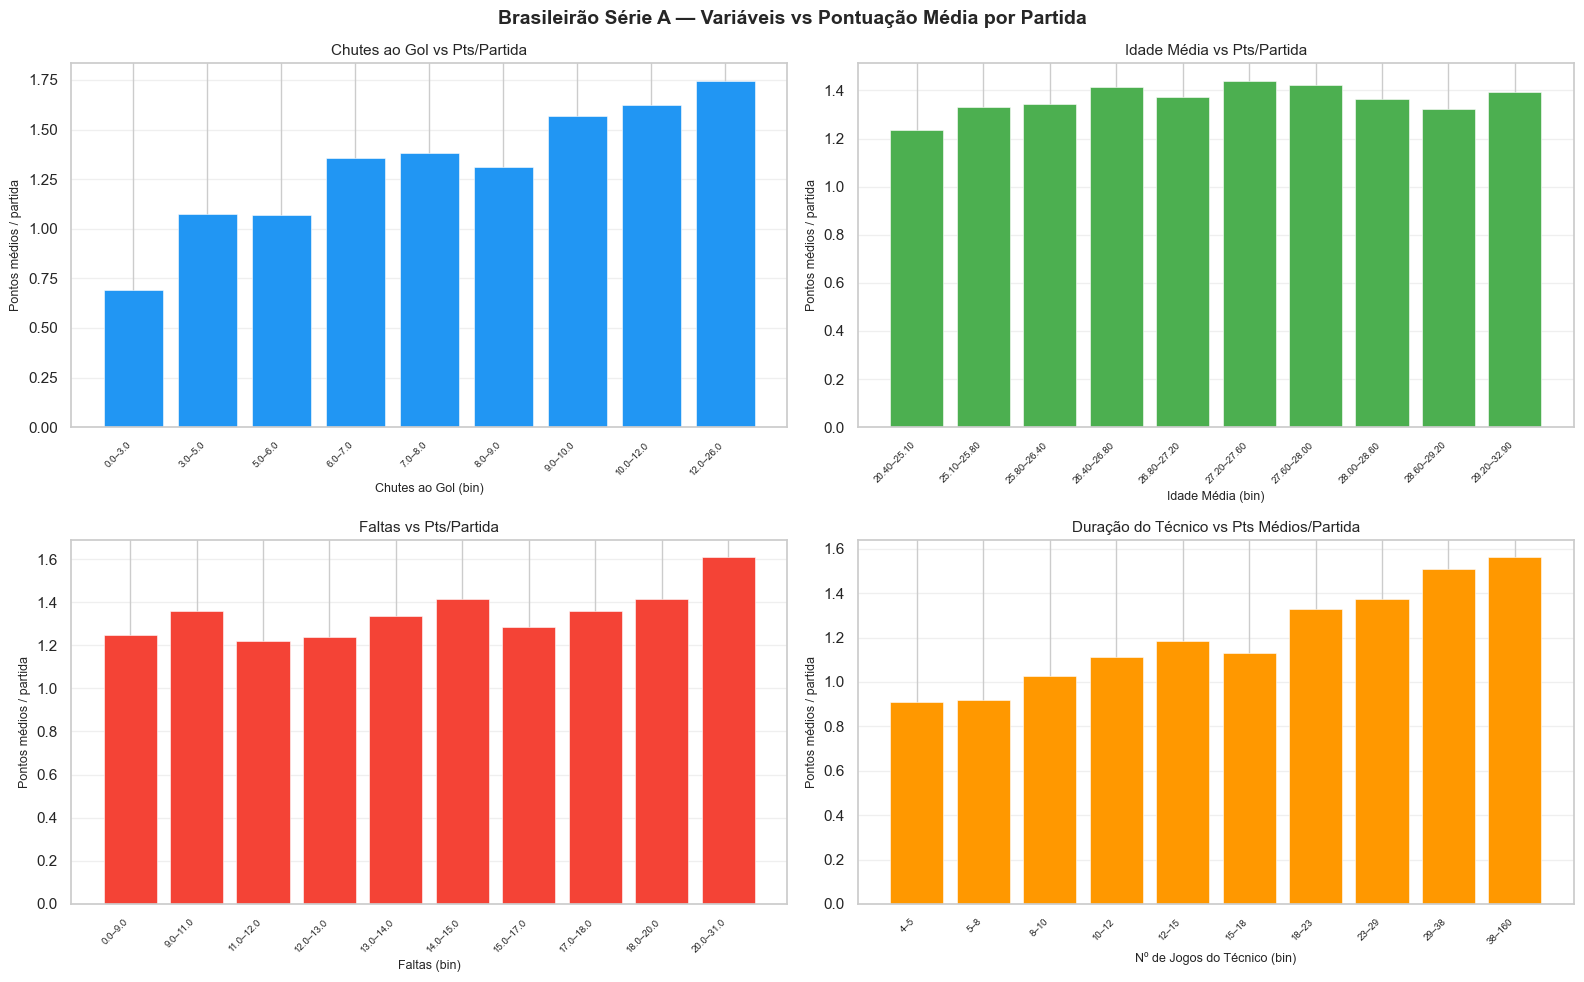

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Brasileirão Série A — Variáveis vs Pontuação Média por Partida', fontsize=14, fontweight='bold')
 
# Helpers
def plot_tabela(ax, tabela, titulo, xlabel, cor):
    vals = tabela['pontuacao_por_partida' if 'pontuacao_por_partida' in tabela.columns else 'pontuacao_media_por_partida'].values
    ax.bar(range(len(vals)), vals, color=cor, edgecolor='white', linewidth=0.4)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Pontos médios / partida', fontsize=9)
    # Ticks: mostra apenas ~8 labels para não poluir
    step = max(1, len(vals) // 8)
    ax.set_xticks(range(0, len(vals), step))
    ax.set_xticklabels(tabela.index[::step], rotation=45, ha='right', fontsize=7)
    ax.grid(axis='y', alpha=0.3)
 
plot_tabela(axes[0, 0], tabela_chutes,   'Chutes ao Gol vs Pts/Partida',    'Chutes ao Gol (bin)',  '#2196F3')
plot_tabela(axes[0, 1], tabela_idade,    'Idade Média vs Pts/Partida',       'Idade Média (bin)',    '#4CAF50')
plot_tabela(axes[1, 0], tabela_faltas,   'Faltas vs Pts/Partida',            'Faltas (bin)',         '#F44336')
 
# Técnicos tem coluna com nome diferente
vals_tec = tabela_tecnicos['pontuacao_media_por_partida'].values
axes[1, 1].bar(range(len(vals_tec)), vals_tec, color='#FF9800', edgecolor='white', linewidth=0.4)
axes[1, 1].set_title('Duração do Técnico vs Pts Médios/Partida', fontsize=11)
axes[1, 1].set_xlabel('Nº de Jogos do Técnico (bin)', fontsize=9)
axes[1, 1].set_ylabel('Pontos médios / partida', fontsize=9)
step_tec = max(1, len(vals_tec) // 8)
axes[1, 1].set_xticks(range(0, len(vals_tec), step_tec))
axes[1, 1].set_xticklabels(tabela_tecnicos.index[::step_tec], rotation=45, ha='right', fontsize=7)
axes[1, 1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('histogramas_brasileirao.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Teste de Hipótese

In [14]:
#CRIANDO HIPÓTESE NULA

GRUPOS        = list('ABCDEFGHI')    # 9 grupos fixos
POPSIZE_NULA  = 2700                 # tamanho da população nula
POPSIZE_TESTE = 2700                 # tamanho da população de teste

In [15]:
todos_pontos = np.concatenate([
    df_gestao['pontos_mandante'].values,
    df_gestao['pontos_visitante'].values
])
media_brasileirao = np.mean(todos_pontos)
print(f"\nMédia geral de pontos/participação no Brasileirão: {media_brasileirao:.4f}")


Média geral de pontos/participação no Brasileirão: 1.3652


In [16]:
# 2. Geração da população nula
#    Cada um dos 9 grupos recebe (media_brasileirao * 100) membros,
#    depois redimensiona para POPSIZE_NULA mantendo as proporções.
# ------------------------------------------------------------------------------
def gerar_populacao_nula(media, popsize=POPSIZE_NULA):
    contagens_brutas = np.array([round(media * 100)] * 9, dtype=int)
    proporcoes       = contagens_brutas / contagens_brutas.sum()
    contagens_finais = np.round(proporcoes * popsize).astype(int)
    # corrige diferença de arredondamento para bater o popsize exato
    diff = popsize - contagens_finais.sum()
    contagens_finais[np.argmax(contagens_finais)] += diff
    return np.repeat(GRUPOS, contagens_finais)
 
pop_nula = gerar_populacao_nula(media_brasileirao, POPSIZE_NULA)

def dist_empirica(pop):
    grupos, contagens = np.unique(pop, return_counts=True)
    d = dict(zip(grupos, contagens / contagens.sum()))
    return np.array([d.get(g, 0.0) for g in GRUPOS])
 
def tvd(p, q):
    return 0.5 * np.sum(np.abs(p - q))
 
dist_nula = dist_empirica(pop_nula)

In [17]:
#COLOQUEI REAMSSOTRA DE TAMANHO 100.000 SÓ PARA TESTAR 
def distribuicao_tvd_nula(pop_nula, n_reamostras=100000):
    dist_ref = dist_empirica(pop_nula)
    n        = len(pop_nula)
    tvds     = np.empty(n_reamostras)
    for i in range(n_reamostras):
        amostra = np.random.choice(pop_nula, size=n, replace=True)
        tvds[i] = tvd(dist_empirica(amostra), dist_ref)
    return tvds
 
print("Calculando distribuição de TVD da hipótese nula (10.000 reamostras)...")
np.random.seed(42)
tvd_dist_nula = distribuicao_tvd_nula(pop_nula, n_reamostras=10000)
print(f"  TVD nula — média: {tvd_dist_nula.mean():.5f} | 95º percentil: {np.percentile(tvd_dist_nula, 95):.5f}")

Calculando distribuição de TVD da hipótese nula (10.000 reamostras)...
  TVD nula — média: 0.02172 | 95º percentil: 0.03185


In [18]:
# Função de teste
#    Parâmetros:
#      tabela_bins   — pd.Series com pontuação média por bin (qualquer nº de bins)
#      tvd_dist_nula — vetor de TVDs da hipótese nula (pré-calculado)
#      nome          — string identificadora para os gráficos
#    Retorna dict com: tvd_obs, p_value, dist_teste, dist_nula, valores_9, rejeitada
# 
def testar_distribuicao(tabela_bins, tvd_dist_nula, nome, popsize=POPSIZE_TESTE):
    valores = tabela_bins.values.astype(float)
    k       = len(valores)
 
    # Reagrupa em exatamente 9 bins por divisão de índices em fatias iguais
    if k != 9:
        indices   = np.array_split(np.arange(k), 9)
        valores_9 = np.array([np.nanmean(valores[ix]) for ix in indices])
    else:
        valores_9 = valores.copy()
 
    # Substitui NaN pela média dos valores válidos
    media_valida = np.nanmean(valores_9)
    valores_9    = np.where(np.isnan(valores_9), media_valida, valores_9)
 
    # Gera população de teste: cada grupo A..I recebe (pontuação_média * 100) membros
    contagens_brutas = np.maximum(np.array([round(v * 100) for v in valores_9], dtype=int), 1)
    proporcoes       = contagens_brutas / contagens_brutas.sum()
    contagens_finais = np.round(proporcoes * popsize).astype(int)
    diff             = popsize - contagens_finais.sum()
    contagens_finais[np.argmax(contagens_finais)] += diff
    pop_teste        = np.repeat(GRUPOS, contagens_finais)
 
    dist_teste = dist_empirica(pop_teste)
    dist_ref   = dist_empirica(gerar_populacao_nula(media_brasileirao, POPSIZE_NULA))
    tvd_obs    = tvd(dist_teste, dist_ref)
 
    # p-value: proporção de TVDs nulos >= TVD observado
    p_value = np.mean(tvd_dist_nula >= tvd_obs)
 
    return {
        'nome'      : nome,
        'tvd_obs'   : tvd_obs,
        'p_value'   : p_value,
        'dist_teste': dist_teste,
        'dist_nula' : dist_ref,
        'valores_9' : valores_9,
        'rejeitada' : p_value < 0.05,
    }

In [19]:
# 
# Aplica o teste às 4 distribuições calculadas anteriormente
# 
serie_chutes  = tabela_chutes['pontuacao_por_partida']
serie_idade   = tabela_idade['pontuacao_por_partida']
serie_faltas  = tabela_faltas['pontuacao_por_partida']
serie_tecnico = tabela_tecnicos['pontuacao_media_por_partida']
 
resultados = [
    testar_distribuicao(serie_chutes,  tvd_dist_nula, 'Chutes ao Gol'),
    testar_distribuicao(serie_idade,   tvd_dist_nula, 'Idade Média'),
    testar_distribuicao(serie_faltas,  tvd_dist_nula, 'Faltas'),
    testar_distribuicao(serie_tecnico, tvd_dist_nula, 'Duração do Técnico'),
]
 
print("\n=== RESULTADOS DOS TESTES ===")
for r in resultados:
    status = "REJEITADA" if r['rejeitada'] else "ASSUMIDA "
    print(f"  {r['nome']:22s} | TVD = {r['tvd_obs']:.5f} | p-value = {r['p_value']:.4f} | H0 {status}")


=== RESULTADOS DOS TESTES ===
  Chutes ao Gol          | TVD = 0.09370 | p-value = 0.0000 | H0 REJEITADA
  Idade Média            | TVD = 0.01481 | p-value = 0.8946 | H0 ASSUMIDA 
  Faltas                 | TVD = 0.03185 | p-value = 0.0535 | H0 ASSUMIDA 
  Duração do Técnico     | TVD = 0.07296 | p-value = 0.0000 | H0 REJEITADA


C:\Users\lucas\AppData\Local\Temp\ipykernel_90168\178178134.py:69: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\lucas\AppData\Local\Temp\ipykernel_90168\178178134.py:70: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig('teste_hipotese.png', dpi=150, bbox_inches='tight')
c:\Users\lucas\OneDrive\Área de Trabalho\Códigos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


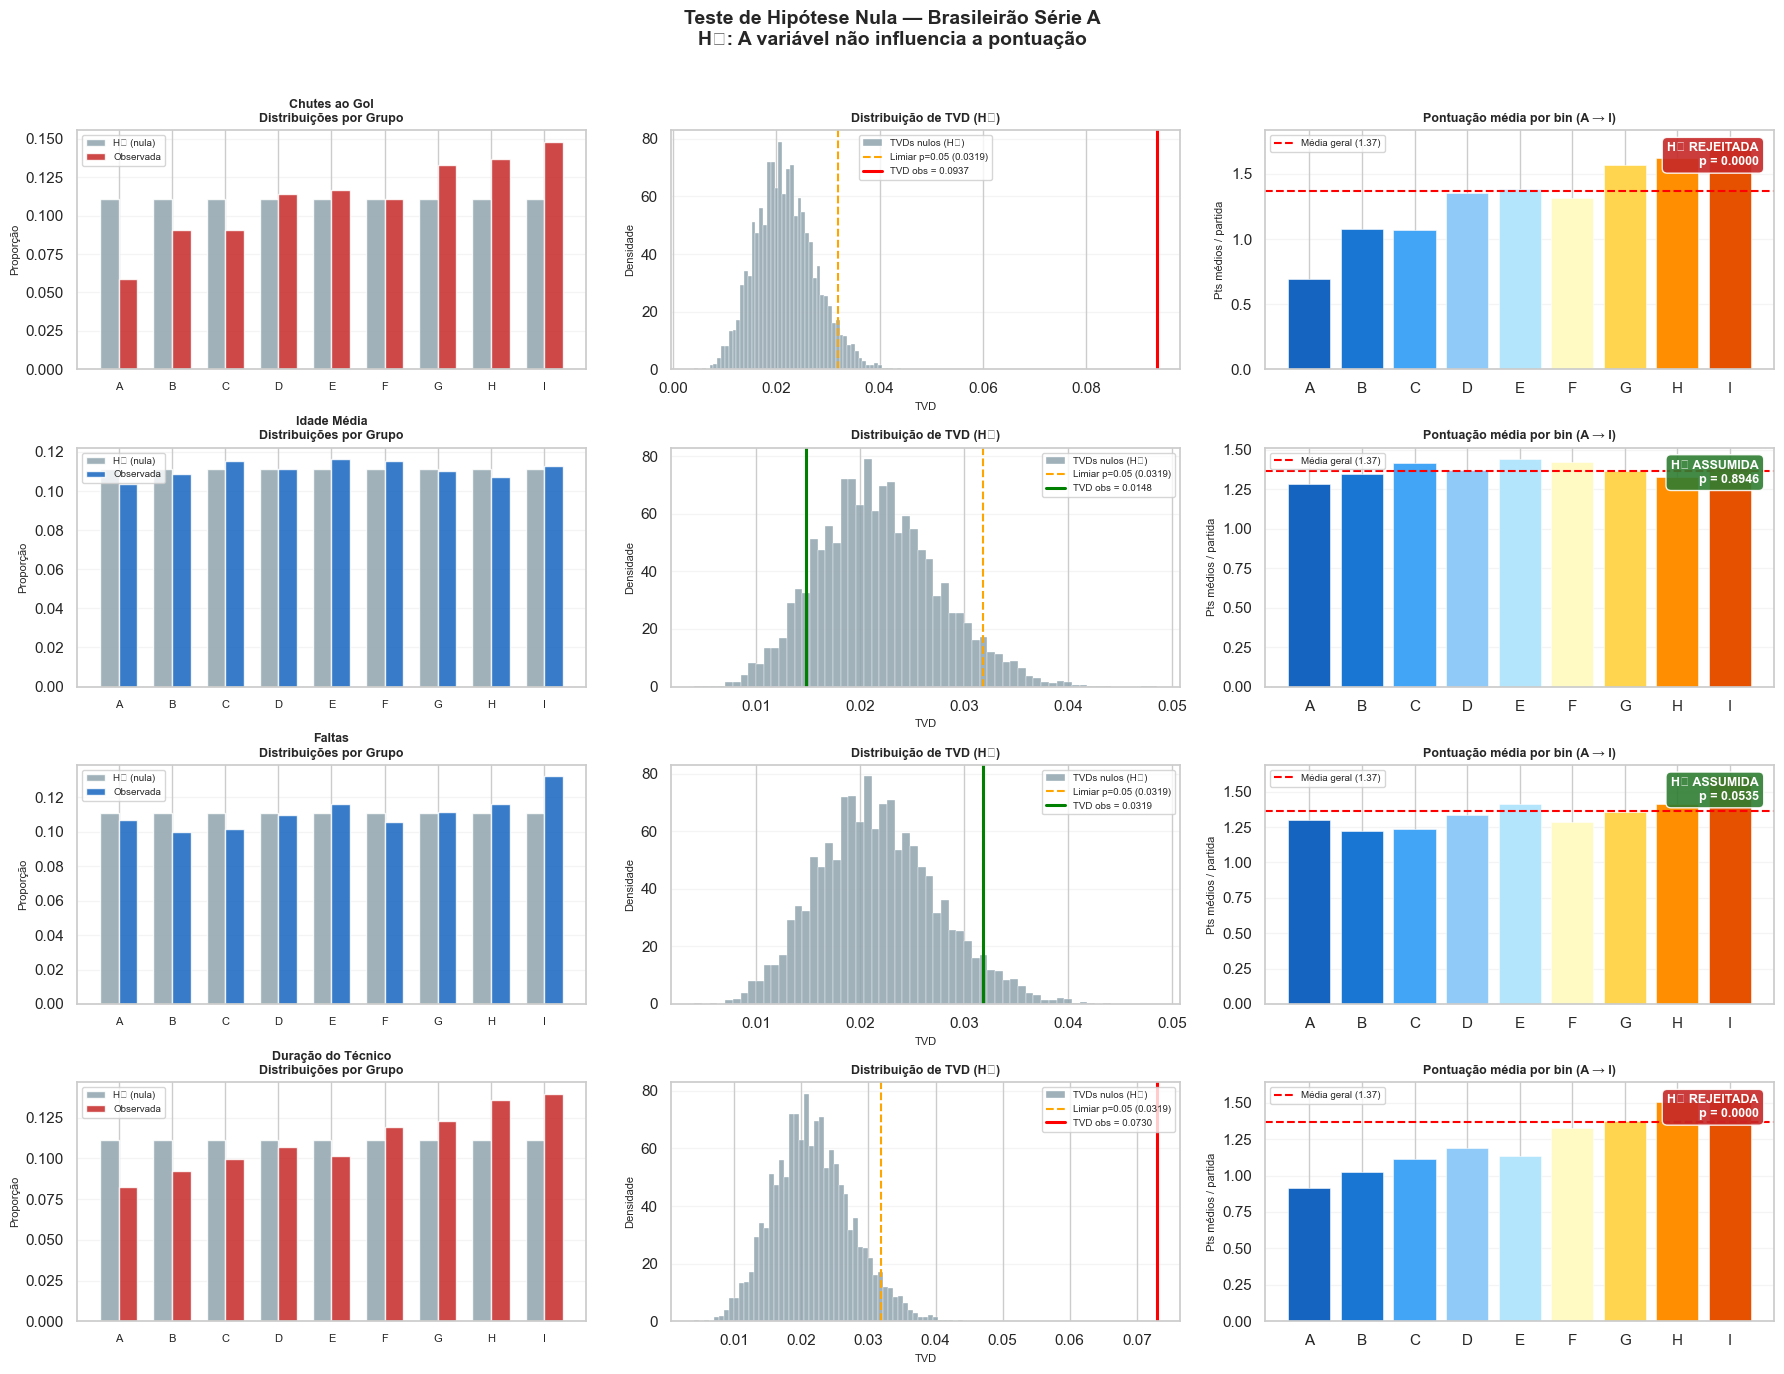

Gráfico salvo em teste_hipotese.png


In [20]:
# 
# Gráfico final — 4 linhas x 3 painéis
#    Col 1: distribuições por grupo A..I (H0 vs observada)
#    Col 2: histograma dos TVDs nulos + linha do TVD observado
#    Col 3: pontuação média por bin A→I com selo de decisão
# 
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Teste de Hipótese Nula — Brasileirão Série A\n'
    'H₀: A variável não influencia a pontuação',
    fontsize=14, fontweight='bold', y=0.98
)
 
cores_grupo = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9', '#B3E5FC',
               '#FFF9C4', '#FFD54F', '#FF8F00', '#E65100']
 
for i, res in enumerate(resultados):
 
    # --- Painel 1: distribuições por grupo ---
    ax1 = fig.add_subplot(4, 3, i * 3 + 1)
    x = np.arange(9)
    w = 0.35
    ax1.bar(x - w/2, res['dist_nula'],  w, label='H₀ (nula)',  color='#90A4AE', alpha=0.85)
    ax1.bar(x + w/2, res['dist_teste'], w, label='Observada',
            color='#C62828' if res['rejeitada'] else '#1565C0', alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(GRUPOS, fontsize=8)
    ax1.set_title(f"{res['nome']}\nDistribuições por Grupo", fontsize=9, fontweight='bold')
    ax1.set_ylabel('Proporção', fontsize=8)
    ax1.legend(fontsize=7)
    ax1.grid(axis='y', alpha=0.2)
 
    # --- Painel 2: distribuição de TVDs nulos + TVD observado ---
    ax2 = fig.add_subplot(4, 3, i * 3 + 2)
    ax2.hist(tvd_dist_nula, bins=60, color='#90A4AE', edgecolor='white',
             linewidth=0.3, alpha=0.85, density=True, label='TVDs nulos (H₀)')
    p95 = np.percentile(tvd_dist_nula, 95)
    ax2.axvline(p95, color='orange', linewidth=1.5, linestyle='--',
                label=f'Limiar p=0.05 ({p95:.4f})')
    ax2.axvline(res['tvd_obs'],
                color='red' if res['rejeitada'] else 'green',
                linewidth=2.2, linestyle='-',
                label=f"TVD obs = {res['tvd_obs']:.4f}")
    ax2.set_title('Distribuição de TVD (H₀)', fontsize=9, fontweight='bold')
    ax2.set_xlabel('TVD', fontsize=8)
    ax2.set_ylabel('Densidade', fontsize=8)
    ax2.legend(fontsize=7)
    ax2.grid(axis='y', alpha=0.2)
 
    # --- Painel 3: pontuação média por bin A..I com selo de decisão ---
    ax3 = fig.add_subplot(4, 3, i * 3 + 3)
    ax3.bar(GRUPOS, res['valores_9'], color=cores_grupo, edgecolor='white', linewidth=0.4)
    ax3.axhline(media_brasileirao, color='red', linewidth=1.5, linestyle='--',
                label=f'Média geral ({media_brasileirao:.2f})')
    ax3.set_title('Pontuação média por bin (A → I)', fontsize=9, fontweight='bold')
    ax3.set_ylabel('Pts médios / partida', fontsize=8)
    ax3.legend(fontsize=7)
    ax3.grid(axis='y', alpha=0.2)
 
    cor_selo = '#C62828' if res['rejeitada'] else '#2E7D32'
    texto    = (f"H₀ REJEITADA\np = {res['p_value']:.4f}"
                if res['rejeitada'] else
                f"H₀ ASSUMIDA\np = {res['p_value']:.4f}")
    ax3.text(0.97, 0.95, texto, transform=ax3.transAxes,
             fontsize=9, fontweight='bold', color='white',
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=cor_selo, alpha=0.9))
 
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('teste_hipotese.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em teste_hipotese.png")

In [21]:

def bootstrap_medias_por_bin(bin_pontos_dict, n_reamostras=10000):
    """
    Parâmetros
    ----------
    bin_pontos_dict : dict  {int -> list}
        Chave = índice do bin, valor = lista de pontuações brutas das partidas.
    n_reamostras : int
        Número de reamostras bootstrap por bin.
 
    Retorna
    -------
    list de np.ndarray
        Um array de 'n_reamostras' médias para cada bin, na ordem dos índices.
    """
    distribs = []
    for i in sorted(bin_pontos_dict.keys()):
        pop = np.array(bin_pontos_dict[i], dtype=float)
        if len(pop) == 0:
            distribs.append(np.full(n_reamostras, np.nan))
            continue
        medias = np.empty(n_reamostras)
        for r in range(n_reamostras):
            amostra   = np.random.choice(pop, size=len(pop), replace=True)
            medias[r] = amostra.mean()
        distribs.append(medias)
    return distribs
 
 
# --- Roda bootstrap para as 4 tabelas ---
print("\nCalculando intervalos de confiança por bin (bootstrap, 10.000 reamostras)...")
np.random.seed(42)
 
bootstrap_chutes  = bootstrap_medias_por_bin(bin_pontos_chutes)
print("  Chutes ao Gol concluido")
bootstrap_idade   = bootstrap_medias_por_bin(bin_pontos_idade)
print("  Idade Media concluido")
bootstrap_faltas  = bootstrap_medias_por_bin(bin_pontos_faltas)
print("  Faltas concluido")
bootstrap_tecnico = bootstrap_medias_por_bin(bin_pontos_tec)
print("  Duracao do Tecnico concluido")
 
 



Calculando intervalos de confiança por bin (bootstrap, 10.000 reamostras)...
  Chutes ao Gol concluido
  Idade Media concluido
  Faltas concluido
  Duracao do Tecnico concluido


Gerando o gráfico...


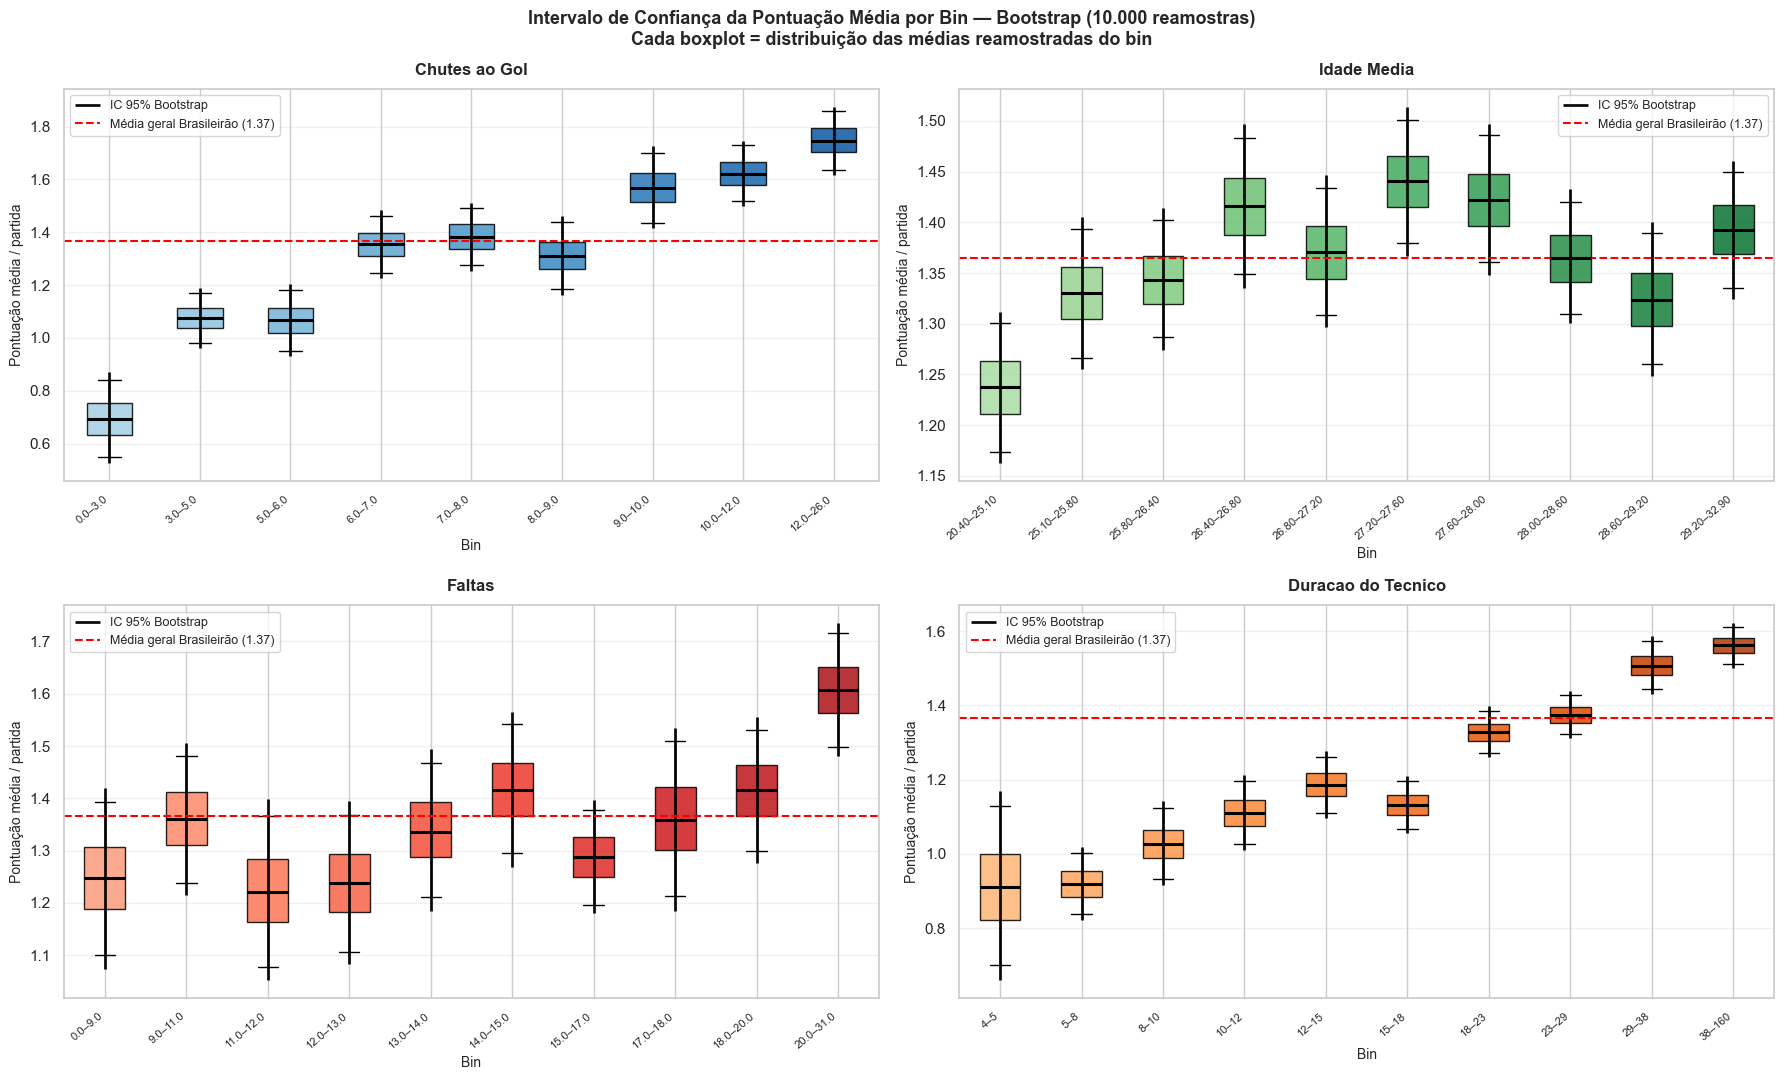

In [22]:
plt.close('all')                    # Fecha todas as figuras anteriores
plt.rcParams['figure.max_open_warning'] = 100

print("Gerando o gráfico...")

# Cria a figura explicitamente
fig, axes = plt.subplots(2, 2, figsize=(18, 11), dpi=100)

fig.suptitle(
    'Intervalo de Confiança da Pontuação Média por Bin — Bootstrap (10.000 reamostras)\n'
    'Cada boxplot = distribuição das médias reamostradas do bin',
    fontsize=13, fontweight='bold'
)

configs = [
    ('Chutes ao Gol',      bootstrap_chutes,  labels_chutes, '#1565C0'),
    ('Idade Media',        bootstrap_idade,   labels_idade,  '#2E7D32'),
    ('Faltas',             bootstrap_faltas,  labels_falta, '#C62828'),
    ('Duracao do Tecnico', bootstrap_tecnico, labels_tec,    '#E65100'),
]

for ax, (nome, distribs_bins, labels, cor) in zip(axes.flat, configs):
    
    dados_validos = [(d, l) for d, l in zip(distribs_bins, labels) 
                     if not np.all(np.isnan(d))]
    dados   = [d for d, _ in dados_validos]
    rotulos = [l for _, l in dados_validos]

    if len(dados) == 0:
        ax.text(0.5, 0.5, 'Sem dados neste gráfico', ha='center', va='center', transform=ax.transAxes)
        continue

    # Boxplot
    bp = ax.boxplot(dados, patch_artist=True, notch=False, showfliers=False,
                    whis=[5, 95],
                    medianprops=dict(color='black', linewidth=2.2))

    # IC 95%
    ic_low = [np.percentile(d, 2.5) for d in dados]
    ic_high = [np.percentile(d, 97.5) for d in dados]
    x_pos = np.arange(len(dados)) + 1
    ax.vlines(x_pos, ic_low, ic_high, color='black', linewidth=2.0, alpha=0.95, label='IC 95% Bootstrap')

    # Coloração das caixas
    cmap = plt.cm.Blues if cor == '#1565C0' else \
           plt.cm.Greens if cor == '#2E7D32' else \
           plt.cm.Reds if cor == '#C62828' else plt.cm.Oranges
    
    for patch, frac in zip(bp['boxes'], np.linspace(0.35, 0.85, len(dados))):
        patch.set_facecolor(cmap(frac))
        patch.set_alpha(0.85)

    ax.axhline(media_brasileirao, color='red', linewidth=1.5, linestyle='--',
               label=f'Média geral Brasileirão ({media_brasileirao:.2f})')

    ax.set_title(nome, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Pontuação média / partida', fontsize=10)
    ax.set_xlabel('Bin', fontsize=10)

    # Rótulos do eixo X
    step = max(1, len(rotulos) // 8)
    ax.set_xticks(range(1, len(rotulos)+1, step))
    ax.set_xticklabels(rotulos[::step], rotation=40, ha='right', fontsize=8)

    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bootstrap_ic_bins.png', dpi=150, bbox_inches='tight')

# Tenta mostrar de formas diferentes
plt.show(block=True)


Calculando distribuicoes de TVD das 4 tabelas vs H0 (10.000 reamostras cada)...


  Chutes ao Gol concluido
  Idade Media concluido
  Faltas concluido
  Duracao do Tecnico concluido

=== BETA E POWER DOS TESTES ===
  Limiar critico (p95 da H0): 0.03185
  Variavel                      Beta    Power       Status
  Chutes ao Gol               0.0000   1.0000    ACIMA 0.8
  Idade Media                 0.8160   0.1840   ABAIXO 0.8
  Faltas                      0.1956   0.8044    ACIMA 0.8
  Duracao do Tecnico          0.0000   1.0000    ACIMA 0.8


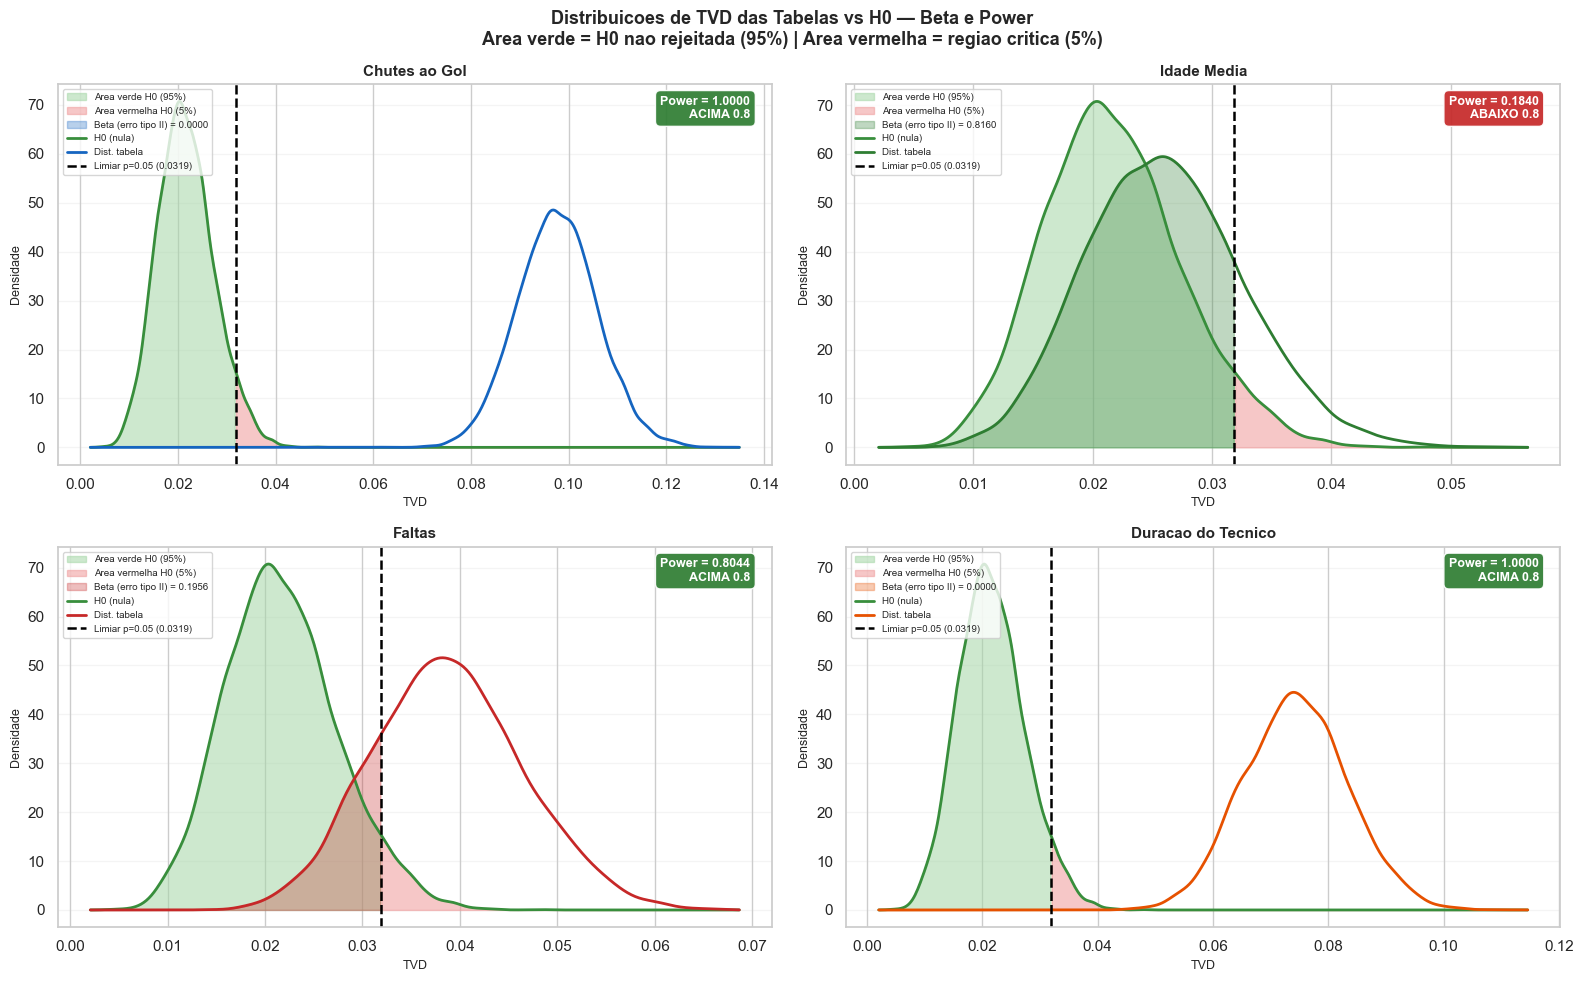

Grafico salvo em tvd_beta_power.png


In [23]:
# DISTRIBUIÇÕES DE TVD DAS 4 TABELAS
# Para cada tabela:
#   1. Constrói a população real (popsize=2700) com base na pontuação de cada bin
#   2. Faz 10.000 reamostras com reposição DESSA população
#   3. Para cada reamostra calcula o TVD contra a própria população real
#   Plota as 4 distribuições resultantes
# ==============================================================================
 
def populacao_de_tabela(tabela_bins, popsize=POPSIZE_TESTE):
    """
    Transforma uma Series de pontuação por bin em uma população de strings A..I.
    Idêntico ao que testar_distribuicao faz internamente.
    """
    valores = tabela_bins.values.astype(float)
    k       = len(valores)
 
    if k != 9:
        indices   = np.array_split(np.arange(k), 9)
        valores_9 = np.array([np.nanmean(valores[ix]) for ix in indices])
    else:
        valores_9 = valores.copy()
 
    media_valida = np.nanmean(valores_9)
    valores_9    = np.where(np.isnan(valores_9), media_valida, valores_9)
 
    contagens_brutas = np.maximum(np.array([round(v * 100) for v in valores_9], dtype=int), 1)
    proporcoes       = contagens_brutas / contagens_brutas.sum()
    contagens_finais = np.round(proporcoes * popsize).astype(int)
    diff             = popsize - contagens_finais.sum()
    contagens_finais[np.argmax(contagens_finais)] += diff
 
    return np.repeat(GRUPOS, contagens_finais)
 
 
def distribuicao_tvd_populacao(pop, dist_nula_ref, n_reamostras=10000):
    """
    Gera n_reamostras reamostras com reposição de `pop`,
    calcula o TVD de cada reamostra contra a distribuição da HIPOTESE NULA
    (dist_nula_ref), NÃO contra a própria população.
    Retorna vetor com n_reamostras TVDs.
    """
    n    = len(pop)
    tvds = np.empty(n_reamostras)
    for i in range(n_reamostras):
        amostra = np.random.choice(pop, size=n, replace=True)
        tvds[i] = tvd(dist_empirica(amostra), dist_nula_ref)
    return tvds
 
 
def calcular_beta(tvd_dist_nula, tvd_dist_tabela):
    """
    Calcula o valor Beta (erro tipo II) para uma tabela:
 
    1. Determina o limiar critico: percentil 95 da distribuicao nula
       (fronteira entre area verde e area vermelha).
    2. Beta = proporcao das amostras da distribuicao da tabela que CAEM
       dentro da area verde (TVD <= limiar), ou seja, que NAO conseguiriam
       rejeitar H0 mesmo sendo da distribuicao alternativa.
    3. Power = 1 - Beta.
    """
    limiar = np.percentile(tvd_dist_nula, 95)          # fronteira verde/vermelho
    beta   = np.mean(tvd_dist_tabela <= limiar)         # CDF da tabela ate o limiar
    power  = 1.0 - beta
    return limiar, beta, power
 
 
# Monta as 4 populacoes reais
pop_chutes  = populacao_de_tabela(serie_chutes)
pop_idade   = populacao_de_tabela(serie_idade)
pop_faltas  = populacao_de_tabela(serie_faltas)
pop_tecnico = populacao_de_tabela(serie_tecnico)
 
# Calcula as 4 distribuicoes de TVD comparando cada populacao com a H0
print("\nCalculando distribuicoes de TVD das 4 tabelas vs H0 (10.000 reamostras cada)...")
np.random.seed(42)
tvd_chutes  = distribuicao_tvd_populacao(pop_chutes,  dist_nula)
print("  Chutes ao Gol concluido")
tvd_idade   = distribuicao_tvd_populacao(pop_idade,   dist_nula)
print("  Idade Media concluido")
tvd_faltas  = distribuicao_tvd_populacao(pop_faltas,  dist_nula)
print("  Faltas concluido")
tvd_tecnico = distribuicao_tvd_populacao(pop_tecnico, dist_nula)
print("  Duracao do Tecnico concluido")
 
# Calcula Beta e Power para cada tabela
limiar_critico = np.percentile(tvd_dist_nula, 95)
 
resultados_power = []
for nome, dist_tab in [
    ('Chutes ao Gol',      tvd_chutes),
    ('Idade Media',        tvd_idade),
    ('Faltas',             tvd_faltas),
    ('Duracao do Tecnico', tvd_tecnico),
]:
    limiar, beta, power = calcular_beta(tvd_dist_nula, dist_tab)
    aprovado = power >= 0.8
    resultados_power.append((nome, dist_tab, beta, power, aprovado))
 
# Resumo numerico
print("\n=== BETA E POWER DOS TESTES ===")
print(f"  Limiar critico (p95 da H0): {limiar_critico:.5f}")
print(f"  {'Variavel':25s} {'Beta':>8} {'Power':>8} {'Status':>12}")
for nome, _, beta, power, aprov in resultados_power:
    status = 'ACIMA 0.8' if aprov else 'ABAIXO 0.8'
    print(f"  {nome:25s} {beta:8.4f} {power:8.4f} {status:>12}")
 
# Cores base de cada variavel
cores_base = ['#1565C0', '#2E7D32', '#C62828', '#E65100']
 
# Grafico: distribuicoes das 4 tabelas com sobreposicao da H0 e areas beta/power
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Distribuicoes de TVD das Tabelas vs H0 — Beta e Power\n'
    'Area verde = H0 nao rejeitada (95%) | Area vermelha = regiao critica (5%)',
    fontsize=13, fontweight='bold'
)
 
from scipy.stats import gaussian_kde
 
for ax, (nome, dist_tab, beta, power, aprovado), cor in zip(
        axes.flat, resultados_power, cores_base):
 
    xs = np.linspace(
        min(tvd_dist_nula.min(), dist_tab.min()) - 0.002,
        max(tvd_dist_nula.max(), dist_tab.max()) + 0.002,
        500
    )
 
    # KDE das duas distribuicoes para curvas suaves
    kde_nula = gaussian_kde(tvd_dist_nula)
    kde_tab  = gaussian_kde(dist_tab)
    y_nula   = kde_nula(xs)
    y_tab    = kde_tab(xs)
 
    # --- Area verde (H0, TVD <= limiar) ---
    mask_verde = xs <= limiar_critico
    ax.fill_between(xs, y_nula, where=mask_verde,
                    color='#A5D6A7', alpha=0.55, label='Area verde H0 (95%)')
 
    # --- Area vermelha (H0, TVD > limiar) ---
    mask_verm = xs >= limiar_critico
    ax.fill_between(xs, y_nula, where=mask_verm,
                    color='#EF9A9A', alpha=0.55, label='Area vermelha H0 (5%)')
 
    # --- Area beta: parte da distribuicao da tabela dentro da area verde ---
    ax.fill_between(xs, y_tab, where=mask_verde,
                    color=cor, alpha=0.30, label=f'Beta (erro tipo II) = {beta:.4f}')
 
    # --- Curvas ---
    ax.plot(xs, y_nula, color='#388E3C', linewidth=2.0, label='H0 (nula)')
    ax.plot(xs, y_tab,  color=cor,       linewidth=2.0, label=f'Dist. tabela')
 
    # --- Limiar critico ---
    ax.axvline(limiar_critico, color='black', linewidth=1.8, linestyle='--',
               label=f'Limiar p=0.05 ({limiar_critico:.4f})')
 
    # --- Selo Power ---
    cor_selo = '#2E7D32' if aprovado else '#C62828'
    status   = 'ACIMA 0.8' if aprovado else 'ABAIXO 0.8'
    ax.text(0.97, 0.97,
            f'Power = {power:.4f}\n{status}',
            transform=ax.transAxes,
            fontsize=9, fontweight='bold', color='white',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=cor_selo, alpha=0.92))
 
    ax.set_title(nome, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('TVD', fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(axis='y', alpha=0.2)
 
plt.tight_layout()
plt.savefig('tvd_beta_power.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em tvd_beta_power.png")

Como a nossa analise de faltas deu muito próximo(o p-valor e o power) do limiar que colocamos, iremos aumentar a nossa amostra do valor de faltas 

In [24]:
# --- Diagnóstico do dataset atual de faltas ---
print("\n=== DIAGNÓSTICO: DATASET FALTAS ORIGINAL (2020-2023) ===")
n_jogos_faltas_original = len(df_scout)
print(f"  Partidas no df_scout (2020-2023):          {n_jogos_faltas_original}")
print(f"  Entradas na tabela de faltas (lado a lado): {n_jogos_faltas_original * 2}  (mandante + visitante)")
total_pontos_faltas_orig = sum(len(v) for v in bin_pontos_faltas.values())
print(f"  Total de registros distribuídos nos bins:  {total_pontos_faltas_orig}")
 
# --- Novo dataset: 2015 a 2023, sem NaN em faltas ---
df_scout_faltas_amplo = df_raw[
    (df_raw['ano_campeonato'] >= 2015) & (df_raw['ano_campeonato'] <= 2023)
].copy()
df_scout_faltas_amplo = df_scout_faltas_amplo.dropna(
    subset=['faltas_mandante', 'faltas_visitante']
)
df_scout_faltas_amplo = calculate_points(df_scout_faltas_amplo)
 
print("\n=== DIAGNÓSTICO: DATASET FALTAS AMPLIADO (2015-2023) ===")
print(f"  Partidas no dataset ampliado:               {len(df_scout_faltas_amplo)}")
print(f"  Entradas totais (mandante + visitante):      {len(df_scout_faltas_amplo) * 2}")
print(f"  Distribuição por ano:")
print(df_scout_faltas_amplo['ano_campeonato'].value_counts().sort_index().to_string())


=== DIAGNÓSTICO: DATASET FALTAS ORIGINAL (2020-2023) ===
  Partidas no df_scout (2020-2023):          1500
  Entradas na tabela de faltas (lado a lado): 3000  (mandante + visitante)
  Total de registros distribuídos nos bins:  3000

=== DIAGNÓSTICO: DATASET FALTAS AMPLIADO (2015-2023) ===
  Partidas no dataset ampliado:               1879
  Entradas totais (mandante + visitante):      3758
  Distribuição por ano:
ano_campeonato
2018    211
2019    168
2020    374
2021    375
2022    373
2023    378


In [25]:
faltas_vals_amp = np.concatenate([
    df_scout_faltas_amplo['faltas_mandante'].values,
    df_scout_faltas_amplo['faltas_visitante'].values
])
faltas_vals_amp = faltas_vals_amp[~np.isnan(faltas_vals_amp)]
 
n_faltas_amp  = len(faltas_vals_amp)

# Alteração principal: 9 bins com quantis (tamanho similar em quantidade de observações)
k_faltas_amp = 9
quantiles = np.linspace(0, 100, k_faltas_amp + 1)
bins_faltas_amp = np.percentile(faltas_vals_amp, quantiles)
 
# Garantir que não haja bins com bordas iguais
bins_faltas_amp = np.unique(bins_faltas_amp)
k_faltas_amp = len(bins_faltas_amp) - 1

bin_pontos_faltas_amp = {i: [] for i in range(k_faltas_amp)}
 
for _, row in df_scout_faltas_amplo.iterrows():
    for lado_var, lado_pts in [
        ('faltas_mandante', 'pontos_mandante'),
        ('faltas_visitante', 'pontos_visitante')
    ]:
        val = row[lado_var]
        pts = row[lado_pts]
        if pd.isna(val) or pd.isna(pts):
            continue
        idx = np.searchsorted(bins_faltas_amp[1:], val, side='right')
        idx = min(idx, k_faltas_amp - 1)
        bin_pontos_faltas_amp[idx].append(pts)
 
labels_faltas_amp = [f"{bins_faltas_amp[i]:.1f}–{bins_faltas_amp[i+1]:.1f}" for i in range(k_faltas_amp)]
media_faltas_amp  = [np.mean(v) if v else np.nan for v in bin_pontos_faltas_amp.values()]
contagem_faltas_amp = [len(v) for v in bin_pontos_faltas_amp.values()]   # <-- Nova linha

tabela_faltas_amp = pd.DataFrame({
    'bin_faltas': labels_faltas_amp,
    'pontuacao_por_partida': media_faltas_amp,
    'n_jogos': contagem_faltas_amp                     # <-- Nova coluna
}).set_index('bin_faltas')
 
print(f"\n=== TABELA: Faltas Ampliada (2015-2023) — {k_faltas_amp} bins (por quantil) ===")
print(tabela_faltas_amp)


=== TABELA: Faltas Ampliada (2015-2023) — 9 bins (por quantil) ===
            pontuacao_por_partida  n_jogos
bin_faltas                                
0.0–9.0                  1.253623      276
9.0–11.0                 1.351064      376
11.0–13.0                1.246503      572
13.0–14.0                1.371166      326
14.0–15.0                1.383598      378
15.0–16.0                1.342618      359
16.0–18.0                1.291667      576
18.0–20.0                1.407674      417
20.0–255.0               1.596234      478



=== TESTE DE HIPÓTESE — FALTAS AMPLIADAS ===
  TVD = 0.02556 | p-value = 0.2467 | H0 ASSUMIDA 


C:\Users\lucas\AppData\Local\Temp\ipykernel_90168\2512817244.py:58: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lucas\AppData\Local\Temp\ipykernel_90168\2512817244.py:59: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig('teste_hipotese_faltas_amp.png', dpi=150, bbox_inches='tight')
c:\Users\lucas\OneDrive\Área de Trabalho\Códigos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


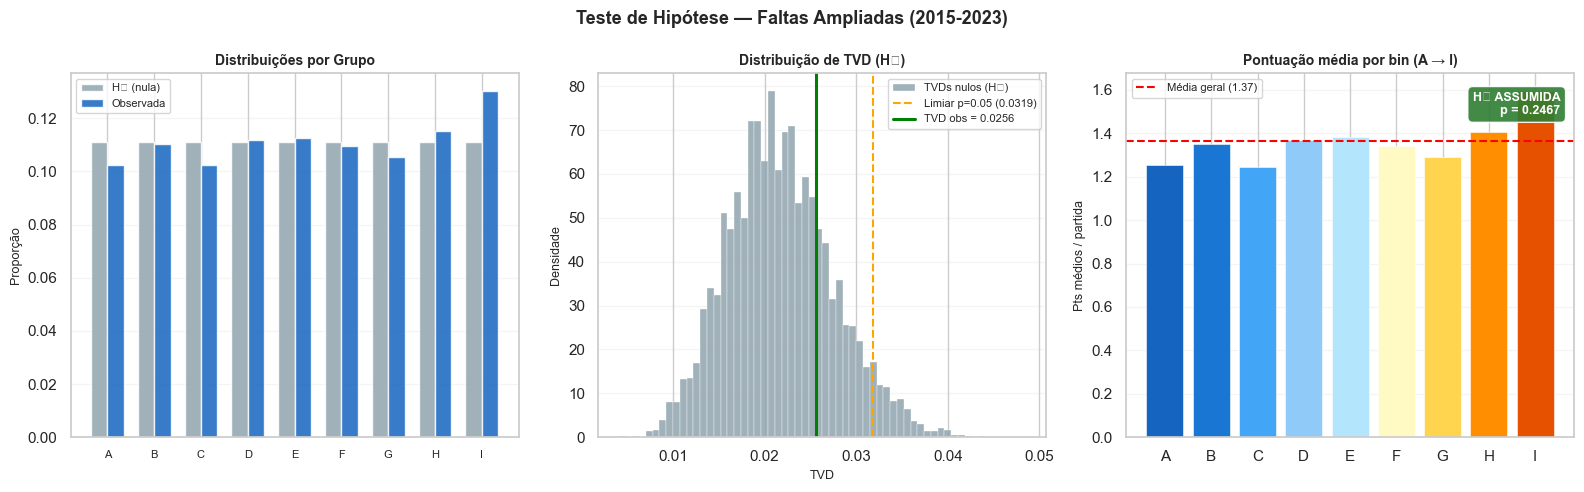

Gráfico salvo em teste_hipotese_faltas_amp.png


In [26]:
serie_faltas_amp = tabela_faltas_amp['pontuacao_por_partida']
 
resultado_faltas_amp = testar_distribuicao(serie_faltas_amp, tvd_dist_nula, 'Faltas (2015-2023)')
 
print("\n=== TESTE DE HIPÓTESE — FALTAS AMPLIADAS ===")
status = "REJEITADA" if resultado_faltas_amp['rejeitada'] else "ASSUMIDA "
print(f"  TVD = {resultado_faltas_amp['tvd_obs']:.5f} | "
      f"p-value = {resultado_faltas_amp['p_value']:.4f} | H0 {status}")
 
# Gráfico do teste de hipótese — faltas ampliadas (3 painéis, igual ao bloco anterior)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Teste de Hipótese — Faltas Ampliadas (2015-2023)',
             fontsize=13, fontweight='bold')
 
res = resultado_faltas_amp
 
# Painel 1: distribuições por grupo
x = np.arange(9); w = 0.35
axes[0].bar(x - w/2, res['dist_nula'],  w, label='H₀ (nula)',  color='#90A4AE', alpha=0.85)
axes[0].bar(x + w/2, res['dist_teste'], w, label='Observada',
            color='#C62828' if res['rejeitada'] else '#1565C0', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(GRUPOS, fontsize=8)
axes[0].set_title('Distribuições por Grupo', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Proporção', fontsize=9); axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.2)
 
# Painel 2: distribuição de TVDs nulos + TVD observado
axes[1].hist(tvd_dist_nula, bins=60, color='#90A4AE', edgecolor='white',
             linewidth=0.3, alpha=0.85, density=True, label='TVDs nulos (H₀)')
p95_nula = np.percentile(tvd_dist_nula, 95)
axes[1].axvline(p95_nula, color='orange', linewidth=1.5, linestyle='--',
                label=f'Limiar p=0.05 ({p95_nula:.4f})')
axes[1].axvline(res['tvd_obs'],
                color='red' if res['rejeitada'] else 'green',
                linewidth=2.2, linestyle='-',
                label=f"TVD obs = {res['tvd_obs']:.4f}")
axes[1].set_title('Distribuição de TVD (H₀)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('TVD', fontsize=9); axes[1].set_ylabel('Densidade', fontsize=9)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.2)
 
# Painel 3: pontuação média por bin A→I com selo
cores_grupo = ['#1565C0','#1976D2','#42A5F5','#90CAF9','#B3E5FC',
               '#FFF9C4','#FFD54F','#FF8F00','#E65100']
axes[2].bar(GRUPOS, res['valores_9'], color=cores_grupo, edgecolor='white', linewidth=0.4)
axes[2].axhline(media_brasileirao, color='red', linewidth=1.5, linestyle='--',
                label=f'Média geral ({media_brasileirao:.2f})')
axes[2].set_title('Pontuação média por bin (A → I)', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Pts médios / partida', fontsize=9)
axes[2].legend(fontsize=8); axes[2].grid(axis='y', alpha=0.2)
cor_selo = '#C62828' if res['rejeitada'] else '#2E7D32'
texto    = (f"H₀ REJEITADA\np = {res['p_value']:.4f}"
            if res['rejeitada'] else f"H₀ ASSUMIDA\np = {res['p_value']:.4f}")
axes[2].text(0.97, 0.95, texto, transform=axes[2].transAxes,
             fontsize=9, fontweight='bold', color='white',
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=cor_selo, alpha=0.9))
 
plt.tight_layout()
plt.savefig('teste_hipotese_faltas_amp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em teste_hipotese_faltas_amp.png")


Calculando IC por bin — Faltas Ampliadas (10.000 reamostras)...


  Concluído


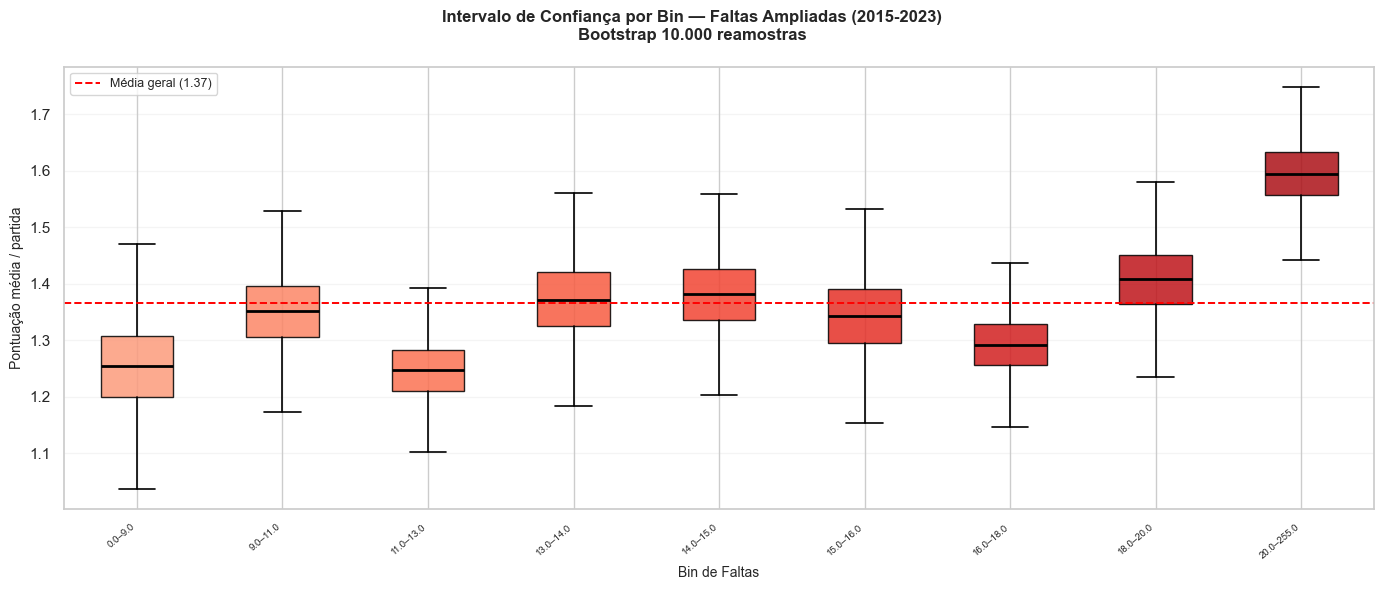

Gráfico salvo em bootstrap_ic_faltas_amp.png


In [27]:
print("\nCalculando IC por bin — Faltas Ampliadas (10.000 reamostras)...")
np.random.seed(42)
bootstrap_faltas_amp = bootstrap_medias_por_bin(bin_pontos_faltas_amp)
print("  Concluído")
 
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Intervalo de Confiança por Bin — Faltas Ampliadas (2015-2023)\n'
             'Bootstrap 10.000 reamostras', fontsize=12, fontweight='bold')
 
dados_validos_amp = [(d, l) for d, l in zip(bootstrap_faltas_amp, labels_faltas_amp)
                     if not np.all(np.isnan(d))]
dados_fa   = [d for d, _ in dados_validos_amp]
rotulos_fa = [l for _, l in dados_validos_amp]
 
bp = ax.boxplot(
    dados_fa,
    patch_artist=True,
    notch=False,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.0),
)
for patch, frac in zip(bp['boxes'], np.linspace(0.35, 0.85, len(dados_fa))):
    patch.set_facecolor(plt.cm.Reds(frac))
    patch.set_alpha(0.85)
 
ax.axhline(media_brasileirao, color='red', linewidth=1.4, linestyle='--',
           label=f'Média geral ({media_brasileirao:.2f})')
ax.set_ylabel('Pontuação média / partida', fontsize=10)
ax.set_xlabel('Bin de Faltas', fontsize=10)
step_fa = max(1, len(rotulos_fa) // 8)
ax.set_xticks(range(1, len(rotulos_fa) + 1, step_fa))
ax.set_xticklabels(rotulos_fa[::step_fa], rotation=40, ha='right', fontsize=7)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
 
plt.tight_layout()
plt.savefig('bootstrap_ic_faltas_amp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em bootstrap_ic_faltas_amp.png")


Calculando Power — Faltas Ampliadas (10.000 reamostras)...
  Concluído

=== POWER — FALTAS AMPLIADAS ===
  Limiar crítico (p95 H0): 0.03185
  Beta:                    0.3517
  Power:                   0.6483
  Status:                  ABAIXO DE 0.8


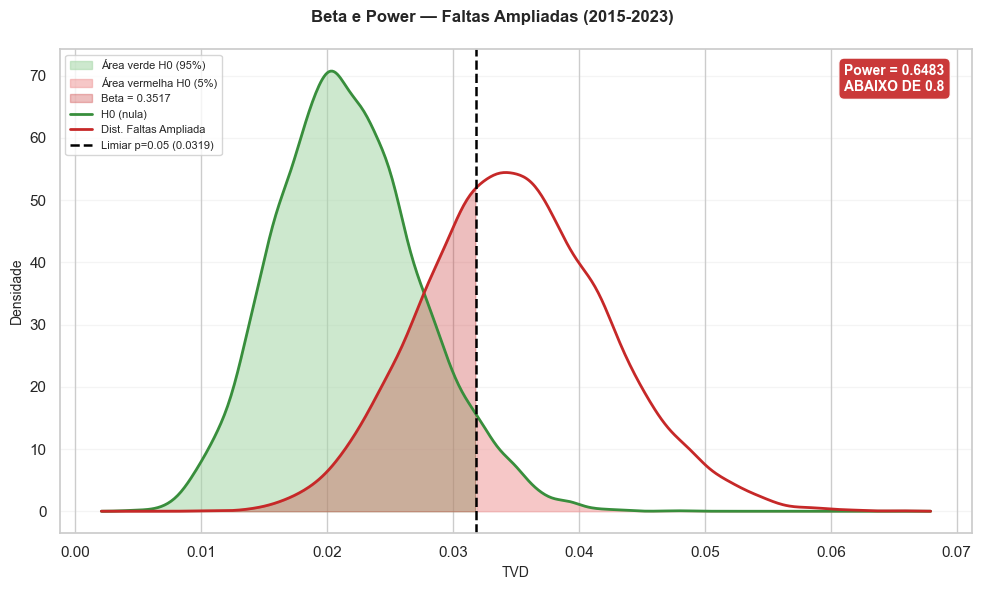

Gráfico salvo em power_faltas_amp.png


In [28]:
print("\nCalculando Power — Faltas Ampliadas (10.000 reamostras)...")
np.random.seed(42)
pop_faltas_amp   = populacao_de_tabela(serie_faltas_amp)
tvd_faltas_amp   = distribuicao_tvd_populacao(pop_faltas_amp, dist_nula)
print("  Concluído")
 
limiar_fa, beta_fa, power_fa = calcular_beta(tvd_dist_nula, tvd_faltas_amp)
aprovado_fa = power_fa >= 0.8
 
print(f"\n=== POWER — FALTAS AMPLIADAS ===")
print(f"  Limiar crítico (p95 H0): {limiar_fa:.5f}")
print(f"  Beta:                    {beta_fa:.4f}")
print(f"  Power:                   {power_fa:.4f}")
print(f"  Status:                  {'ACIMA DE 0.8' if aprovado_fa else 'ABAIXO DE 0.8'}")
 
# Gráfico Beta/Power — faltas ampliadas
from scipy.stats import gaussian_kde as _kde
 
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Beta e Power — Faltas Ampliadas (2015-2023)', fontsize=12, fontweight='bold')
 
xs_fa = np.linspace(
    min(tvd_dist_nula.min(), tvd_faltas_amp.min()) - 0.002,
    max(tvd_dist_nula.max(), tvd_faltas_amp.max()) + 0.002,
    500
)
kde_nula_fa = _kde(tvd_dist_nula)(xs_fa)
kde_tab_fa  = _kde(tvd_faltas_amp)(xs_fa)
 
mask_verde_fa = xs_fa <= limiar_fa
mask_verm_fa  = xs_fa >= limiar_fa
 
ax.fill_between(xs_fa, kde_nula_fa, where=mask_verde_fa,
                color='#A5D6A7', alpha=0.55, label='Área verde H0 (95%)')
ax.fill_between(xs_fa, kde_nula_fa, where=mask_verm_fa,
                color='#EF9A9A', alpha=0.55, label='Área vermelha H0 (5%)')
ax.fill_between(xs_fa, kde_tab_fa, where=mask_verde_fa,
                color='#C62828', alpha=0.30, label=f'Beta = {beta_fa:.4f}')
ax.plot(xs_fa, kde_nula_fa, color='#388E3C', linewidth=2.0, label='H0 (nula)')
ax.plot(xs_fa, kde_tab_fa,  color='#C62828', linewidth=2.0, label='Dist. Faltas Ampliada')
ax.axvline(limiar_fa, color='black', linewidth=1.8, linestyle='--',
           label=f'Limiar p=0.05 ({limiar_fa:.4f})')
 
cor_selo_fa = '#2E7D32' if aprovado_fa else '#C62828'
status_fa   = 'ACIMA DE 0.8' if aprovado_fa else 'ABAIXO DE 0.8'
ax.text(0.97, 0.97, f'Power = {power_fa:.4f}\n{status_fa}',
        transform=ax.transAxes, fontsize=10, fontweight='bold', color='white',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=cor_selo_fa, alpha=0.92))
 
ax.set_xlabel('TVD', fontsize=10); ax.set_ylabel('Densidade', fontsize=10)
ax.legend(fontsize=8, loc='upper left'); ax.grid(axis='y', alpha=0.2)
 
plt.tight_layout()
plt.savefig('power_faltas_amp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em power_faltas_amp.png")

Agora, com uma amostra maior, ficou mais claro que podemos aceitar a hipótese nula. O power ter abaixado é um indício da hipótese nula ser verdadeira, qaundo aumentamos o tamanho da nossa amostra, ela se aproximou mais da hipótese nula, isso fica claro quando vemos que o valor-p aumentou para 0.24, então agora podemos afirmar com maior certeza que aceitaremos a hipótese nula para as faltas.

ASSIM CONCLUÍMOS QUE: 
PARA FALTAS E IDADE MÉDIA DOS TIMES NÓS ASSUMIMOS A HIPÓTESE NULA
PARA CHUTES AO GOL E DURAÇÃO DOS TECNICOS NÓS ASSUMIMOS QUE O RENDIMENTO DE UM TIME É INFLEUNCIADO POR ESSAS MÉTRICAS POSITIVAMENTE 

## 6. Análise de Desempenho (Perguntas de Pesquisa)

### A. Chutes ao gol vs. Rendimento

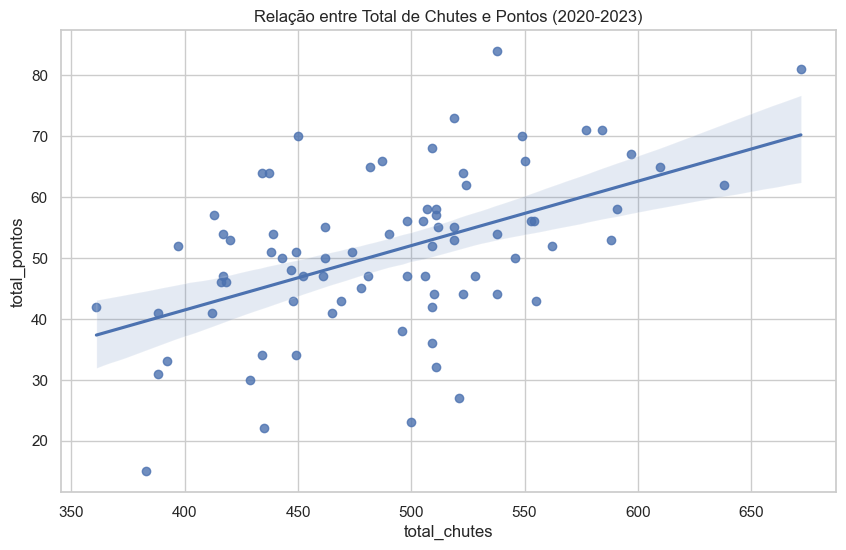

In [29]:
mapping_scout = {
    'chutes_totais': ('chutes_mandante', 'chutes_visitante'),
    'faltas_cometidas': ('faltas_mandante', 'faltas_visitante'),
    'chutes_fora': ('chutes_fora_mandante', 'chutes_fora_visitante')
}
df_scout_unified = unify_team_data(df_scout, mapping_scout)

rendimento_scout = df_scout_unified.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    total_chutes=('chutes_totais', 'sum'),
    total_gols=('gols_pro', 'sum')
).reset_index()

rendimento_scout['eficiencia'] = (rendimento_scout['total_gols'] / rendimento_scout['total_chutes']) * 100

sns.regplot(data=rendimento_scout, x='total_chutes', y='total_pontos')
plt.title('Relação entre Total de Chutes e Pontos (2020-2023)')
plt.show()

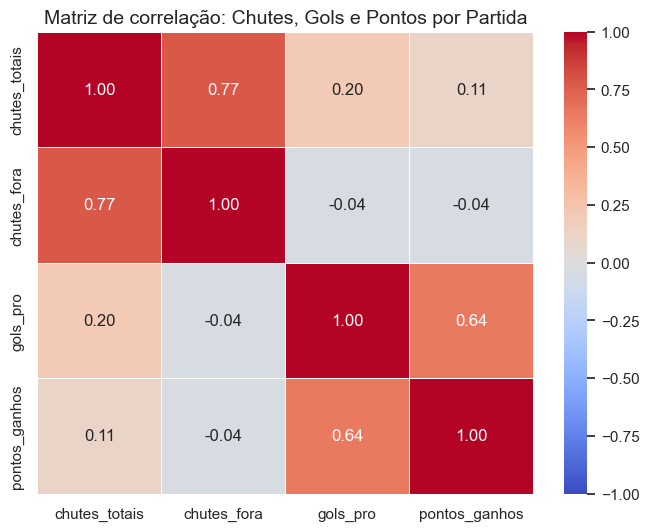

In [30]:
variaveis_correlacao = df_scout_unified[['chutes_totais', 'chutes_fora', 'gols_pro', 'pontos_ganhos']]

matriz_corr = variaveis_correlacao.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='coolwarm',     # Esquema de cores (azul para negativo, vermelho para positivo)
    fmt=".2f",           # Formata para 2 casas decimais
    linewidths=0.5,
    vmin=-1, vmax=1      # Limites da correlação
)

plt.title('Matriz de correlação: Chutes, Gols e Pontos por Partida', fontsize=14)

# Exibindo o gráfico
plt.show()

In [31]:
corr_chutes_pontos = rendimento_scout['total_chutes'].corr(rendimento_scout['total_pontos'])
corr_eficiencia_pontos = rendimento_scout['eficiencia'].corr(rendimento_scout['total_pontos'])

print(f"Correlação (Total de Chutes vs Pontos Totais): {corr_chutes_pontos:.2f}")
print(f"Correlação (Eficiência de Chutes vs Pontos Totais): {corr_eficiencia_pontos:.2f}")

Correlação (Total de Chutes vs Pontos Totais): 0.50
Correlação (Eficiência de Chutes vs Pontos Totais): 0.69


Com base na análise exploratória, concluímos que a quantidade bruta de chutes ao gol não é um indicador forte ou suficiente de rendimento. Embora times que pontuam mais tendam a atacar mais ao longo do ano, a baixíssima correlação por partida (0.11) prova que o sucesso na Série A do Brasileirão não é ditado pelo volume, mas sim pela eficiência (taxa de conversão de gols por chute). A agressividade ofensiva só se traduz em posição na tabela quando acompanhada de precisão.

### B. Permanência de Treinadores vs. Rendimento

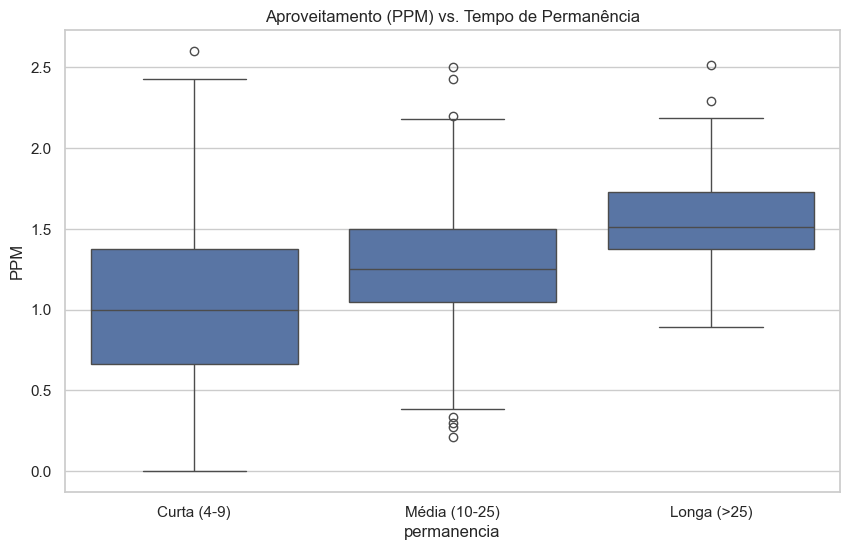

In [32]:
mapping_gestao = {
    'tecnico': ('tecnico_mandante', 'tecnico_visitante'),
    'idade_media': ('idade_media_titular_mandante', 'idade_media_titular_visitante')
}
df_gestao_unified = unify_team_data(df_gestao, mapping_gestao)

# Identificando Eras de Treinadores
df_gestao_unified = df_gestao_unified.sort_values(['ano_campeonato', 'time', 'data'])
df_gestao_unified['troca'] = (df_gestao_unified['tecnico'] != df_gestao_unified['tecnico'].shift(1)) | \
                             (df_gestao_unified['time'] != df_gestao_unified['time'].shift(1))
df_gestao_unified['era_id'] = df_gestao_unified['troca'].cumsum()

trabalhos = df_gestao_unified.groupby(['era_id', 'tecnico', 'time', 'ano_campeonato']).agg(
    jogos=('pontos_ganhos', 'count'),
    pontos=('pontos_ganhos', 'sum')
).reset_index()

trabalhos = trabalhos[trabalhos['jogos'] >= 4].copy()

trabalhos['PPM'] = trabalhos['pontos'] / trabalhos['jogos']

def categorize_duration(n):
    if n < 10: return 'Curta (4-9)'
    if n <= 25: return 'Média (10-25)'
    return 'Longa (>25)'

trabalhos['permanencia'] = trabalhos['jogos'].apply(categorize_duration)

sns.boxplot(data=trabalhos, x='permanencia', y='PPM', order=['Curta (4-9)', 'Média (10-25)', 'Longa (>25)'])
plt.title('Aproveitamento (PPM) vs. Tempo de Permanência')
plt.show()

In [33]:
rendimento_gestao = df_gestao_unified.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    idade_media_temporada=('idade_media', 'mean'), # Média da idade no ano
    trocas_tecnico=('tecnico', lambda x: x.nunique() - 1)  # (Qtd de técnicos únicos - 1) = trocas
).reset_index().sort_values(['ano_campeonato', 'total_pontos'], ascending=[True, False])


rendimento_gestao['posicao_final'] = rendimento_gestao.groupby('ano_campeonato')['total_pontos'].rank(method='first', ascending=False)

# Classificamos se o time manteve o técnico o ano todo (0 trocas) ou não
rendimento_gestao['perfil_gestao'] = np.where(
    rendimento_gestao['trocas_tecnico'] == 0, 
    'Manteve o Técnico', 
    'Trocou de Técnico'
)

C:\Users\lucas\AppData\Local\Temp\ipykernel_90168\2286329475.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


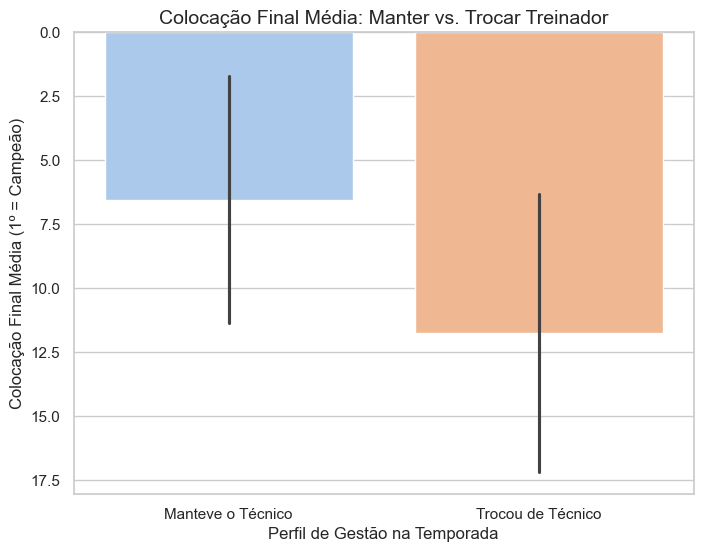

In [34]:
plt.figure(figsize=(8, 6))

# Calculamos a colocação média para quem manteve vs quem trocou
sns.barplot(
    data=rendimento_gestao, 
    x='perfil_gestao', 
    y='posicao_final',
    errorbar='sd', # Mostra o desvio padrão
    palette='pastel'
)

# Invertemos o eixo Y, pois no futebol a 1ª posição (menor número) é a melhor
plt.gca().invert_yaxis()

plt.title('Colocação Final Média: Manter vs. Trocar Treinador', fontsize=14)
plt.xlabel('Perfil de Gestão na Temporada', fontsize=12)
plt.ylabel('Colocação Final Média (1º = Campeão)', fontsize=12)
plt.show()

A análise estatística confirma a hipótese de que o tempo de permanência de um treinador está fortemente associado a um melhor rendimento. A estabilidade técnica reflete diretamente em melhores posições na tabela e maior pontuação média. Contudo, como ponto de discussão para trabalhos futuros, vale ressaltar a questão da causalidade no futebol: os times ganham mais porque mantêm o técnico, ou mantêm o técnico porque estão ganhando? Independentemente da direção causal, a quebra de continuidade no meio da temporada (trabalhos curtos) está estatisticamente ligada ao insucesso.

### C. Faltas Cometidas vs. Rendimento

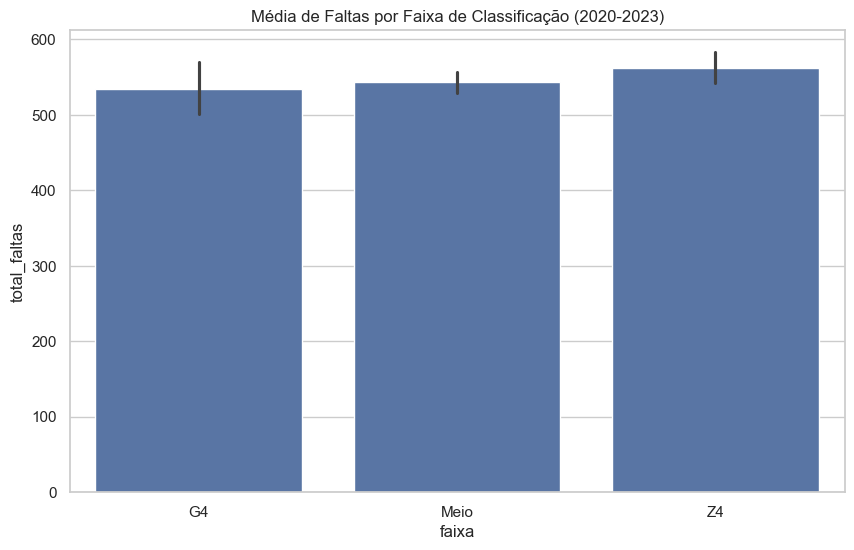

In [35]:
mapping_scout_extended = {
    'chutes_totais': ('chutes_mandante', 'chutes_visitante'),
    'faltas_cometidas': ('faltas_mandante', 'faltas_visitante'),
    'defesas': ('defesas_mandante', 'defesas_visitante')
}
df_scout_unified = unify_team_data(df_scout, mapping_scout_extended)

rendimento_faltas = df_scout_unified.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    total_faltas=('faltas_cometidas', 'sum')
).reset_index()

# Classificação por faixas
rendimento_faltas['rank'] = rendimento_faltas.groupby('ano_campeonato')['total_pontos'].rank(method='first', ascending=False)
rendimento_faltas['faixa'] = np.where(rendimento_faltas['rank'] <= 4, 'G4', 
                                      np.where(rendimento_faltas['rank'] >= 17, 'Z4', 'Meio'))

sns.barplot(data=rendimento_faltas, x='faixa', y='total_faltas', order=['G4', 'Meio', 'Z4'])
plt.title('Média de Faltas por Faixa de Classificação (2020-2023)')
plt.show()

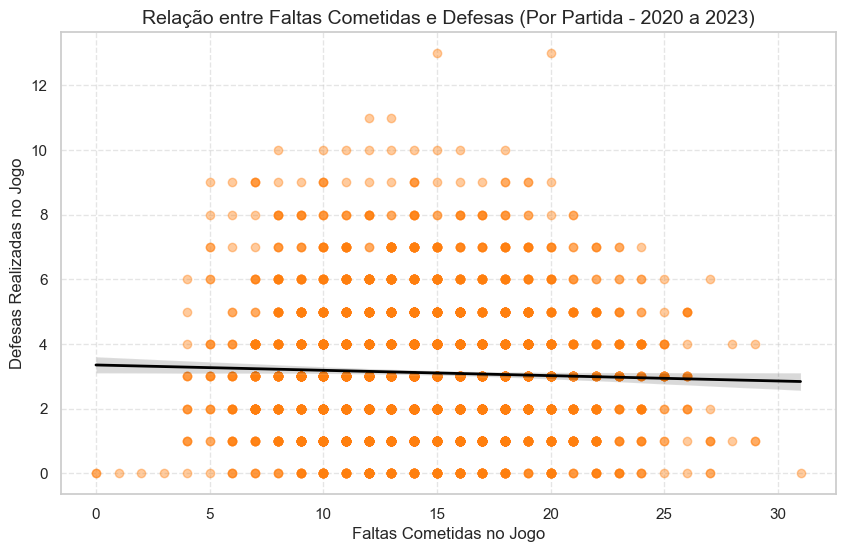

In [36]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_scout_unified, 
    x='faltas_cometidas', 
    y='defesas',
    scatter_kws={'alpha':0.4, 'color': '#ff7f0e'}, # Laranja semi-transparente
    line_kws={'color': 'black', 'linewidth': 2}
)

plt.title('Relação entre Faltas Cometidas e Defesas (Por Partida - 2020 a 2023)', fontsize=14)
plt.xlabel('Faltas Cometidas no Jogo', fontsize=12)
plt.ylabel('Defesas Realizadas no Jogo', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Como a análise do teste de hipótese feito anteriormente mostra, a distribuição de pontos para as diferentes quantidades de faltas nos jogos segue uma distribuição igual, então apesar de termos detectado uma variação negativa no desempenho, ela não é estatisticamente relevante 

### D. Idade Média vs. Rendimento

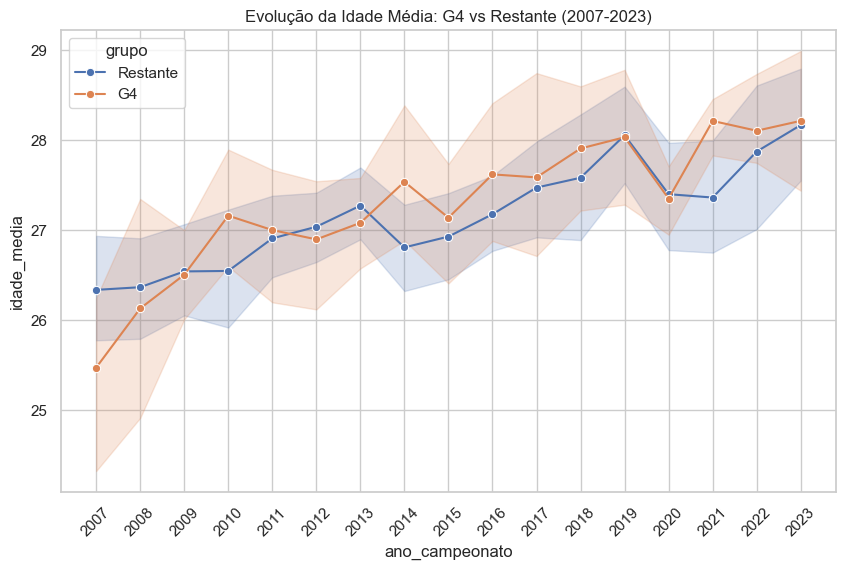

In [37]:
rendimento_idade = df_gestao_unified.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    idade_media=('idade_media', 'mean')
).reset_index()

rendimento_idade['rank'] = rendimento_idade.groupby('ano_campeonato')['total_pontos'].rank(method='first', ascending=False)
rendimento_idade['grupo'] = np.where(rendimento_idade['rank'] <= 4, 'G4', 'Restante')

sns.lineplot(data=rendimento_idade, x='ano_campeonato', y='idade_media', hue='grupo', marker='o')
plt.title('Evolução da Idade Média: G4 vs Restante (2007-2023)')
plt.xticks(rendimento_idade['ano_campeonato'].unique(), rotation=45)
plt.show()

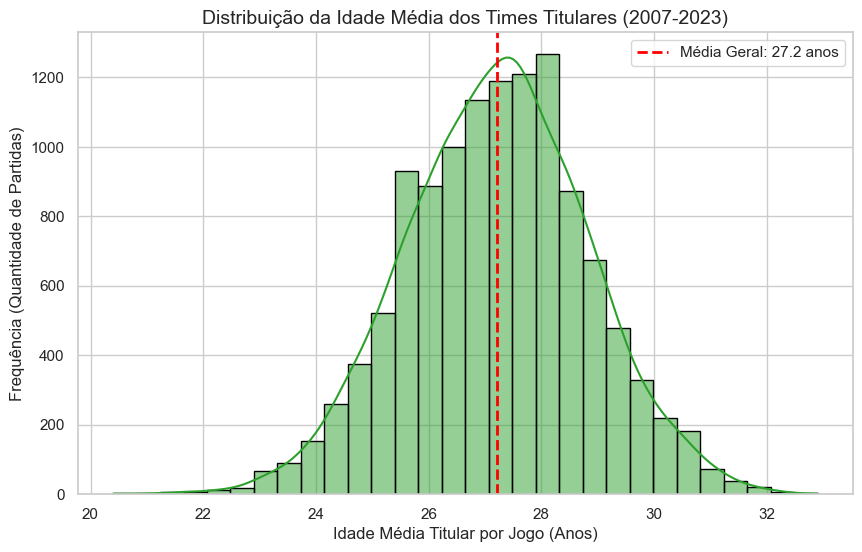

In [38]:
plt.figure(figsize=(10, 6))

# Usando o dataset unificado para ter a distribuição de todos os jogos
sns.histplot(
    data=df_gestao_unified, 
    x='idade_media', 
    bins=30, 
    kde=True, # Adiciona a linha de densidade (curva do sino)
    color='#2ca02c', # Verde
    edgecolor='black'
)

# Adicionando uma linha vertical para a média geral
media_geral = df_gestao_unified['idade_media'].mean()
plt.axvline(media_geral, color='red', linestyle='dashed', linewidth=2, label=f'Média Geral: {media_geral:.1f} anos')

plt.title('Distribuição da Idade Média dos Times Titulares (2007-2023)', fontsize=14)
plt.xlabel('Idade Média Titular por Jogo (Anos)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Partidas)', fontsize=12)
plt.legend()
plt.show()

In [39]:
print("Estatísticas Descritivas da Idade Média (2007-2023):")
print(f"Média Geral (Todos os times): {df_gestao_unified['idade_media'].mean():.2f}")
print(f"Média do G4 (Top 4): {rendimento_gestao[rendimento_gestao['posicao_final'] <= 4]['idade_media_temporada'].mean():.2f}")
print(f"Média do Z4 (Rebaixados): {rendimento_gestao[rendimento_gestao['posicao_final'] >= 17]['idade_media_temporada'].mean():.2f}")

Estatísticas Descritivas da Idade Média (2007-2023):
Média Geral (Todos os times): 27.21
Média do G4 (Top 4): 27.29
Média do Z4 (Rebaixados): 27.31


Nossa análise conclui que a idade média não é um fator determinante para o rendimento de um time no Campeonato Brasileiro.  

Ao longo de 16 anos de dados, a diferença de idade média entre o pelotão de elite (G4) e os times rebaixados (Z4) é de apenas 0.02 anos, uma margem estatisticamente irrelevante. Isso indica que tanto os campeões quanto os rebaixados adotam uma estratégia de montagem de elenco muito similar, buscando aquele "padrão" de 27 anos que mescla juventude e experiência.  

Portanto, o sucesso na tabela não é explicado pela idade do time no papel, mas sim pela qualidade técnica, tática e por fatores de gestão — como vimos anteriormente na análise sobre a permanência dos treinadores.

## 5. Conclusões

1. **Volume vs. Eficiência:** A quantidade bruta de chutes não é o principal fator de sucesso, mas sim a eficiência na conversão.
2. **Estabilidade Técnica:** Trabalhos de longa duração (>25 jogos) apresentam PPM significativamente superior a trocas constantes.
3. **Disciplina:** Conforme o teste de hipótese mostrou, o rendimento para os diferentes números de faltas seguem a distribuição da hipótese nula
4. **Idade:** Não há uma diferença significativa na idade média entre campeões e rebaixados, mantendo-se o padrão em torno de 27 anos.